<strong><b><font size="5">Time Series Analysis and Forecasting in Python</font></b></strong>

<table>
    <tr style="border-top: 1px solid black; border-bottom: 1px solid black">
        <td>
            <h1>Analyse des sentiments</h1>
        </td>
    </tr>
</table>


<table>
    <tr style="text-align: center;vertical-align:left">
    <td style="border-top: 1px solid black; border-bottom: 1px solid black;vertical-align: middle">     
 <h1>Plan du rapport</h1>
    </td>
   </tr>
</table>

<table style="width: 100%">
<tr>
    <td style="width: 15%">
    </td>
    <td style="width: 70%; text-align:left">
        <a href="#1"><h1>I. Introduction </h1></a><br>
           &nbsp; <a href="#presentation">I.1 Présentation du problème et des données </a><br>
           &nbsp; <a href="#preparation">I.2 Préparation et Visualisation des données</a><br><br>


<a href="#2"><h1>II. Comment représenter un texte sous forme de vecteur? </h1></a><br><br>
    &nbsp; <a href="#ohe">II.1 One Hot Encoding </a><br>
    &nbsp; <a href="#pre">II.2 Preprocessing</a><br>
        &emsp; <a href="#sp">II.2.1 Stopwords et Ponctuations</a><br>
        &emsp; <a href="#hiu">II.2.2 Handles (Identifiant) et url</a><br>
        &emsp; <a href="#sl">II.2.3 Steming (radical) et lowercasting (miniscule)</a><br>
    &nbsp; <a href="#fnp">II.3 Fréquences négatives et positives</a><br>
        &emsp; <a href="#eef">II.3.1 Extraction d'entité avec les fréquences</a><br><br>

<a href="#3"><h1>III. Régression Logistique </h1></a><br><br>
    &nbsp; <a href="#sig">III.1 Sigmoïde</a><br>
    &nbsp; <a href="#rlrs">III.2 Régression logistique: Régression et Sigmoïde</a><br>
    &nbsp; <a href="#pdrl">III.3 Préparer les données pour la Régression Logstique</a><br>
    &nbsp; <a href="#trl">III.4 Tester la Régression Logistique</a><br>
        &emsp; <a href="#vpaet">III.4.1 Vérifier les performances à l'aide de l'ensemble de test</a><br>
        &emsp; <a href="#tnpt">III.4.2 Test sur nos propres Tweet</a><br><br>


<a href="#4"><h1>IV. Naïve Bayes</h1></a><br><br>
    &nbsp; <a href="#mdl">IV.1 Modification des labels</a><br>
    &nbsp; <a href="#anbf">IV.2 Autour de Naïve Bayes et des fréquences</a><br>
    &nbsp; <a href="#cstpn">IV.3 Comment savoir si un tweet est positif ou négatif?</a><br>
        &emsp; <a href="#estpar">IV.3.1 Ratio et Laplacian Smoothing</a><br>
        &emsp; <a href="#ra">IV.3.2 Ratio Antérieur</a><br>
        &emsp; <a href="#pl">IV.3.3 Prior, Logprior et Log-vraisemblance</a><br>
    &nbsp; <a href="#tnb">IV.3 Tester Naïves Bayes</a><br>
         &emsp; <a href="#vpaet1">III.4.1 Vérifier les performances à l'aide de l'ensemble de test</a><br>
        &emsp; <a href="#tnpt1">III.4.2 Test sur nos propres Tweet</a><br><br>


<a href="#5"><h1>V. Prévisions avec les méthodes stochastiques</h1></a><br>
    &nbsp; <a href="#ar">V.1 Les processus AR</a><br>
    &nbsp; <a href="#ma">V.2 Les processus MA</a><br>
    &nbsp; <a href="#arma">V.3 Les processus ARMA</a><br>
    &nbsp; <a href="#arima">V.4 Les processus ARIMA</a><br>
        &emsp; <a href="#autoarima">V.4.1 Auto Arima</a><br>
    &nbsp; <a href="#sarima">V.5 Les processus SARIMA</a><br>
        &emsp; <a href="#autosarima">V.4.1 Auto Sarima</a><br>
    </td>
    <td style="width: 0%">
    </td>
</tr>
</table>


<a href="#6"><h1>VI. Référence </h1></a><br><br>
   </td>
    <td style="width: 0%">
    </td>
</tr>
</table>


## <a name="generalite"> Généralités sur les séries temporelles </a>

# Analyse des sentiments

# <a name="1">I. Introduction</a>

Exemple de tache, on considère cette phrase comme étant un **tweet**: I'm happy because I am Learning NLP

On doit deviner le sentiment s'agit t-il d'un sentiment:

- Positive = 1

ou bien

- Négative = 0

## <a name="presentation"> Présentation du problème et des données </a>

Le but sera d'utiliser un modèle de classification binaire qui nous permettra de prédire le sentiment d'un tweet donné. Cependant on doit d'abord représenter le tweet comme des features afin de l'utiliser dans notre modèle de classification binaire

In [ ]:
import nltk                                # # Bibliothèque Python pour NLP
from nltk.corpus import twitter_samples    # Twitter_samples dataset de NLTK
import matplotlib.pyplot as plt
import random
import string
import numpy as np

Dans cette partie nous utiliserons NLTK

In [ ]:
nltk.download('twitter_samples')

[nltk_data] Downloading package twitter_samples to
[nltk_data]     /home/jafuno/nltk_data...
[nltk_data]   Package twitter_samples is already up-to-date!


True

## <a name="preparation"> Préparation et Visualisation des données </a>

In [ ]:
# sélectionner l'ensemble des tweets positifs et négatifs
all_positive_tweets = twitter_samples.strings('positive_tweets.json')
all_negative_tweets = twitter_samples.strings('negative_tweets.json')

In [ ]:
print('Nombre de tweets positifs: ', len(all_positive_tweets))
print('Number de tweets négatifs: ', len(all_negative_tweets))

print('\nLe type de all_positive_tweets est: ', type(all_positive_tweets))
print('Le type des tweets en entrées est: ', type(all_negative_tweets[0]))

Nombre de tweets positifs:  5000
Number de tweets négatifs:  5000

Le type de all_positive_tweets est:  <class 'list'>
Le type des tweets en entrées est:  <class 'str'>


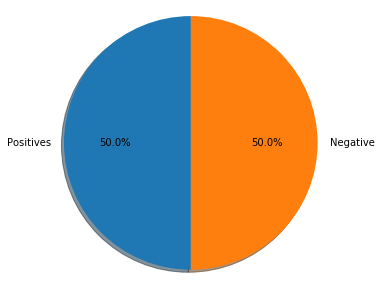

In [ ]:

fig = plt.figure(figsize=(5, 5))

# labels des deux classes
labels = 'Positives', 'Negative'

# Tailles pour chaque part de classe
sizes = [len(all_positive_tweets), len(all_negative_tweets)]

# Déclarer un diagramme circulaire, où les tranches seront ordonnées et tracées dans
#le sens inverse des aiguilles d'une montre :
plt.pie(sizes, labels=labels, autopct='%1.1f%%',
        shadow=True, startangle=90)

# Un rapport d'aspect égal assure que la tarte est dessinée comme un cercle.
plt.axis('equal')


plt.show()

In [ ]:
# afficher un tweet positif en vert
print('\033[92m' + all_positive_tweets[random.randint(0,5000)])

# afficher un tweet négatif en rouge
print('\033[91m' + all_negative_tweets[random.randint(0,5000)])

Hi #Gorgeous @TillieModel have  a nice swim with your sis!! Can I get a #Birthday shout out please it would make my day?? #Perfection :) xx
@The5BallOver @Radio702 :-( It's not a challenge though. Please check our FB page for entries and rather do a substitution. Thanks!


# <a name="2">II. Comment représenter un texte sous forme de vecteur ?</a>

- On doit d'abord construire un **Vocabulaire**

Supposons que nous avons une liste de Tweets ou bien un **corpus** de tweet.

[tweet_1,tweet_2,tweet_3....................tweet_m] = [I'm happy because I am Learning NLP, .........,I hated the movie]

Puis notre Vocabualaire V = [I, am, happy, because, learning, NLP,..........., hated, the, movie],  il s'agit de la liste des mots unique de tout nos tweets. (pas de répétition I et am ne sont pas répété ici)


## <a name="ohe"> One Hot Encoding </a>

- Ensuite on choisis un tweet parmis les m (Feature extraction) par exemple choisisons: I'm happy because I am Learning NLP ,on attribue 1 au mot qui apparaisent dans ce tweet et 0 aux autres

[I, am, happy, because, learning, NLP,..........., hated, the, movie]

[1,  1,     1,       1,        1,   1,...........,     0,   0,     0]


On peut remarquer qu'on risque d'avoir un petit nombre de valeur non nulle (Sparse representation)

Nous avons ici un problème de Sparse representation:

- Le Vocabulaire peut avoir une très grande taille $n = |V|$
- n sera également la taille de nos paramètre du modèle de classification binaire, on peut avoir un long temps de prédiction et d'entrainement

## <a name="prep"> Preprocessing( Prétraitement)</a>

### <a name="sp">Stopwords et Ponctuations </a>

Exemple soit un tweet :  @D.Jafuno and @Youuu are Tuning a great Ai model at https://github.com/ !!!!

Il faut comparer ce tweet à deux liste Stopwords( les mots vides sans importances) et Ponctuations
quelques Stopwords et Ponctuations

 Stopwords    Ponctuations                               
    and           ,
    is            !  
    are           .
    at            :
    has           ;
    for           '
    a             "

dans le tweet on supprimera les mots qui apparraissent dans Stopwords et dans ponctuation sauf que la ponctuation dans un nom ou une adresse email ou internet ne compte pas dans notre tweet seul: ! sera considéré comme une ponctuation

Au final en retirant stopwords et Ponctuations

Le tweet deviendra:
- @DJafuno @Youuu Tuning great Ai model https://github.com/

### <a name="hiu">Handles (Identifiant) et url</a>

Identifiant et url ne sont pas nécssaire pour l'analyse des sentiments, on les supprimes

Le tweet devient alors :  
- Tuning great Ai model

### <a name="sl">Steming (radical du mot) and Lowercasting (miniscule)</a>


Exemple Tun radical de Tune, tuned, Tuning on gardera le radical du mot

GREAT Great great ces 3 mots ont la meme signification on gardera les mots en miniscules comme great

Le tweet devient alors:   
- tune  great ai model

Pour Résumer :
- Eliminer identifiant et url
- Tokenization: couper le tweet (chaine de caractère) en tokens (mots dans un vecteur)
- Supprimer les Stopwords
- Convertir chaque mot en son radical (Stemming)
- Convertir tout les mots en miniscule ( cela prendra moins de place dans la mémoire)

Voici donc nos tweets représenter sous formes de matrices, implémentons celà

In [ ]:
print('Un tweet positif: ',all_positive_tweets[276])

Un tweet positif:  @PinkPeoniesBlog @helloprettysa definitely the Hazel Food Market in Brooklyn, Pta :) &gt;&gt; http://t.co/ySQkhNDo2B


In [ ]:
tweet =all_positive_tweets[276]

Supprimer l'url et "&"

In [ ]:
print('\033[92m' + tweet)
print('\033[94m')

import re

# supprimer les hyperliens (urls)
tweet2 = re.sub(r'https?:\/\/.*[\r\n]*', '', tweet)

# supprimer le &
# en retirant seulement le signe & du mot
#tweet2 = re.sub(r'&', '', tweet2)

print(tweet2)

@PinkPeoniesBlog @helloprettysa definitely the Hazel Food Market in Brooklyn, Pta :) &gt;&gt; http://t.co/ySQkhNDo2B

@PinkPeoniesBlog @helloprettysa definitely the Hazel Food Market in Brooklyn, Pta :) &gt;&gt; 


Supprimer les identifiants, faire la tokenisations et mettre chaque mot en minuscule

In [ ]:
print()
print('\033[92m' + tweet2)
print('\033[94m')

from nltk.tokenize import TweetTokenizer

tokenizer = TweetTokenizer(preserve_case=False, strip_handles=True, reduce_len=True)
#strip_handles= True ne tiendra pas compte des identifiants
#preserve_case=False  met chaque mot en miniscule
tweet_tokens = tokenizer.tokenize(tweet2)

print()
print('tweet tokenizé et sans les identifiants:')
print(tweet_tokens)


@PinkPeoniesBlog @helloprettysa definitely the Hazel Food Market in Brooklyn, Pta :) &gt;&gt; 


tweet tokenizé et sans les identifiants:
['definitely', 'the', 'hazel', 'food', 'market', 'in', 'brooklyn', ',', 'pta', ':)', '>', '>']


Suppression des stops words et de la ponctuation

In [ ]:
#Importer la liste des mots vides en anglais de NLTK
from nltk.corpus import stopwords
nltk.download('stopwords')
stopwords_english = stopwords.words('english')

print('Stop words en anglais:\n')
print(stopwords_english)

print('\nPonctuation:\n')
print(string.punctuation)

Stop words en anglais:

['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're", "you've", "you'll", "you'd", 'your', 'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', "she's", 'her', 'hers', 'herself', 'it', "it's", 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves', 'what', 'which', 'who', 'whom', 'this', 'that', "that'll", 'these', 'those', 'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do', 'does', 'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until', 'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into', 'through', 'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once', 'here', 'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more', 'most', 'other', 'some', 'such', 'no', 'nor', 'not', 'only', 'own',

[nltk_data] Downloading package stopwords to /home/jafuno/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
print()
print('\033[92m')
print(tweet_tokens)
print('\033[94m')

tweets_clean = []

for word in tweet_tokens: # Passez en revue chaque mot de votre liste de tokens
    if (word not in stopwords_english and  # supprimer les stopwords
        word not in string.punctuation):  # supprimer la ponctuation
        tweets_clean.append(word)

print('Suppression des stop words et de la ponctuation:')
print(tweets_clean)



['definitely', 'the', 'hazel', 'food', 'market', 'in', 'brooklyn', ',', 'pta', ':)', '>', '>']

Suppression des stop words et de la ponctuation:
['definitely', 'hazel', 'food', 'market', 'brooklyn', 'pta', ':)']


Prendre le radical des mots

In [ ]:
print()
print('\033[92m')
print(tweets_clean)
print('\033[94m')

# Instancier la classe des radical de mot
from nltk.stem import PorterStemmer
stemmer = PorterStemmer()


tweets_stem = []

for word in tweets_clean:
    stem_word = stemmer.stem(word)  # radical du mot
    tweets_stem.append(stem_word)  # ajouter à la liste

print('radical des mots:')
print(tweets_stem)



['definitely', 'hazel', 'food', 'market', 'brooklyn', 'pta', ':)']

radical des mots:
['definit', 'hazel', 'food', 'market', 'brooklyn', 'pta', ':)']


On remarque que les mots

Maintenant nous allons écrire une fonction **`process_tweet`** qui reprend l'ensemble des étapes précédentes

In [ ]:
import re
import string
import numpy as np

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import TweetTokenizer


def process_tweet(tweet):
    """Fonction  process_tweet.
    Entrée :
        tweet : une chaîne de caractères contenant un tweet
    Sortie :
        tweets_clean : une liste de mots contenant le tweet traité

    """
    stemmer = PorterStemmer()
    stopwords_english = stopwords.words('english')
    # supprimer les tickers boursiers comme $GE
    tweet = re.sub(r'\$\w*', '', tweet)
    # supprimer l'ancien texte retweet "RT"
    tweet = re.sub(r'^RT[\s]+', '', tweet)
    # supprimer les hyperliens
    tweet = re.sub(r'https?:\/\/.*[\r\n]*', '', tweet)
    # supprimer les hashtags
    # en retirant seulement le signe dièse # du mot
    tweet = re.sub(r'#', '', tweet)
    # tokenize tweets
    tokenizer = TweetTokenizer(preserve_case=False, strip_handles=True,
                               reduce_len=True)
    tweet_tokens = tokenizer.tokenize(tweet)

    tweets_clean = []
    for word in tweet_tokens:
        if (word not in stopwords_english and  # supprimer les stopwords
                word not in string.punctuation):  # supprimer les ponctuations
            # tweets_clean.append(word)
            stem_word = stemmer.stem(word)  # racine du mot
            tweets_clean.append(stem_word)

    return tweets_clean



In [ ]:
tweet =all_positive_tweets[276]
tweet

'@PinkPeoniesBlog @helloprettysa definitely the Hazel Food Market in Brooklyn, Pta :) &gt;&gt; http://t.co/ySQkhNDo2B'

In [ ]:
process_tweet(tweet)

['definit', 'hazel', 'food', 'market', 'brooklyn', 'pta', ':)']

In [ ]:
process_tweet('@DJafuno and @Youuu are Tuning a great Ai model at https://github.com/ !!!!')

['tune', 'great', 'ai', 'model']

On retrouve bien les meme liste

## <a name="fnp"> Fréquences négatives et positives</a>

On considère un corpus de 4 tweets, 2 positifs et 2 négatifs

les positifs:

- I am happy because I am learning NLP

- I am happy


les négatifs:

- I am sad, I am not learning NLP

- I am sad

Soit nos 2 tweets positif:

I am happy because I am learning NLP
I am happy

On les représentes en un tableau de 2 colonnes correspondant au Vocabulaire lié au corpus à la fréquence PosFreq(1) (avec 1 car il s'agit de la classe positive) de chaque mot dans ces phrases positives:

Vocabulaire     PosFreq(1)
    I              3
    am             3   
  happy            2
  because          1
  learning         1
    NLP            1
   sad             0
   not             0

le mot I apparait 3 fois dans l'ensemble des phrases positives am aussi etc

De meme pour nos 2 tweets négatifs on obtiendra

Vocabulaire     NegFreq(0)
    I              3
    am             3   
  happy            0
  because          0
  learning         1
    NLP            1
   sad             2
   not             1

On appelle le **Dictionnaire de fréquence** l'ensemble de ces 3 colonnes  Vocabulaire, PosFreq(1) et NegFreq(0)

Nous allons implémenter une fonction **`build_freqs`** qui représente le dictionnaire de fréquence** sans les stop words et avec le radical des mots en minuscule rapppelons qu'en python un dictionnaire d pourrait s'écrire de cette manière d={clé0:valeur0, clé1:valeur1} tel que d[clé0]=valeur0 et d[clé1]=valeur1,dans notre cas chaque clé sera un tuple à 2 éléments contenant une paire de **(mot, y)**. Le "mot" est un élément d'un tweet traité, tandis que "y" est un entier représentant le corpus : 1 pour les tweets positifs et 0 pour les tweets négatifs. La valeur associée à cette clé est le nombre de fois que ce mot apparaît dans le corpus spécifié. Par exemple :

```
# "folowfriday" apparaît 25 fois dans les tweets positifs
("followfriday", 1.0) : 25

# "shame" apparaît 19 fois dans les tweets négatifs
("shame", 0.0) : 19
```

In [ ]:
def build_freqs(tweets, ys):
    """Construire des fréquences.
    Entrée :
        tweets : une liste de tweets
        ys : un tableau m x 1 avec la classe de sentiment de chaque tweet
            (soit 0 ou 1)
    Sortie :
        freqs : un dictionnaire mettant en correspondance chaque paire (mot, sentiment) avec sa
        fréquence
    """
    # Convertir le tableau en liste car le zip a besoin d'un itérable.
    # La compression est nécessaire ou la liste se retrouve avec un seul élément.
    # Notez aussi que ce n'est qu'un NOP si ys est déjà une liste.
    yslist = np.squeeze(ys).tolist()

    # Commencez avec un dictionnaire vide et remplissez-le en passant en boucle sur tous les tweets
    # et sur tous les mots traités dans chaque tweet.
    freqs = {}
    for y, tweet in zip(yslist, tweets):
        for word in process_tweet(tweet):
            pair = (word, y)
            if pair in freqs:
                freqs[pair] += 1
            else:
                freqs[pair] = 1

    return freqs


In [ ]:
# faire un tableau numérique représentant les classes des tweets
#labels = np.append(np.ones((len(all_positive_tweets))), np.zeros((len(all_negative_tweets))))
labels=np.append(np.ones(2), np.zeros(2))

In [ ]:
labels

array([1., 1., 0., 0.])

In [ ]:
Tweet= ['I am happy because I am learning NLP','I am happy','I am sad, I am not learning NLP','I am sad']

In [ ]:
freqs = build_freqs(Tweet, labels)

In [ ]:
freqs

{('happi', 1.0): 2,
 ('learn', 1.0): 1,
 ('nlp', 1.0): 1,
 ('sad', 0.0): 2,
 ('learn', 0.0): 1,
 ('nlp', 0.0): 1}

### <a name="eef"> Extraction d'entité avec les fréquences </a>

Maintenant qu'on a construit notre **dictionnaire de fréquence** on peut l'utiliser pour **extraire les fonctionnalités (features)** utiles pour l'analyse des sentiments.

A quoi ressemble ses fonctionnalités

$$X_m=[1,\sum_w freqs(w,1), \sum_w freqs(w,0)]$$

avec :
- w pour word qui correspond à chaque mot du Vocabulaire
- freqs(w,1) qui correspond à la colonne PosFreq(1) pour chaque mot w du Vocabulaire
- freqs(w,0) qui correspond à la colonne NegFreq(0) pour chaque mot w du Vocabulaire

ici pour le tweet:  **I am sad I am not learning NLP** de la partie précédente on a $X_m$ = [1,8,11] il s'agit d'une représentation de ce tweet en dimension 3

Pour chaque tweet (N mots de longueurs différentes)
- Construire un vecteur de mot sans les mots inutiles  (m listes de mot de tailles différentes)
- Construire le vecteur $X_m$ de taille 3
- Construire une matrice X de taille m x 3


$$X = \left[
\begin{array}{cccc}
1 & X_1^{(1)} & X_2^{(1)} \\
1 & X_1^{(2)}  & X_2^{(2)} \\
\vdots & \vdots & \vdots \\
1 & X_1^{(m)} & X_2^{(m)})
\end{array}
\right]
$$


Implémentons une fonction **`extract_features`** pour calculer $X_m$

In [ ]:
def extract_features(tweet, freqs):
    '''
    Input:
        tweet: a list of words for one tweet
        freqs: a dictionary corresponding to the frequencies of each tuple (word, label)
    Output:
        x: a feature vector of dimension (1,3)
    '''
    # process_tweet tokenize etc
    word_l = process_tweet(tweet)

    # vecteur nul de taille 1,3 pour chaque X_m
    x = np.zeros((1, 3))

    #la premiere colonne ne contient que des 1
    x[0,0] = 1

    #pour tout les mots de la liste process_tweet
    for word in word_l:

        # incrementer le nombre de mots pour la classe positive 1
        x[0,1] += freqs.get((word, 1.0),0)

        # incrementer le nombre de mots pour la classe negative 0
        x[0,2] += freqs.get((word, 0.0),0)

    assert(x.shape == (1, 3))
    return x

Faison un test sur nos donnée de tweet

In [ ]:
# faire un tableau numérique représentant les classes des tweets
labels = np.append(np.ones((len(all_positive_tweets))), np.zeros((len(all_negative_tweets))))

On aura un corpus d'un tweet

In [ ]:
tweet =all_positive_tweets[276]

In [ ]:
tweet

'@PinkPeoniesBlog @helloprettysa definitely the Hazel Food Market in Brooklyn, Pta :) &gt;&gt; http://t.co/ySQkhNDo2B'

On place notre tweet dans une liste pour la dfonction **build_freqs**

In [ ]:
tweet=[tweet]

In [ ]:
tweet

['@PinkPeoniesBlog @helloprettysa definitely the Hazel Food Market in Brooklyn, Pta :) &gt;&gt; http://t.co/ySQkhNDo2B']

A partir de nos deux fonctions précédente implémentons un code qui nous permet de **calculer la matrice X**

In [ ]:
m=1# car un seul tweet
freqs = build_freqs(tweet, labels)
X= np.zeros((m,3))
for i in range(m):
    X[i,:]= extract_features(tweet[i], freqs)



In [ ]:
X

array([[1., 7., 0.]])

Maintenant que l'on a représenter notre copus de tweet en matrice de features nous pouvons utiliser nos modèle de prédictions binaire  

# <a name="3">III. Regression Logistique </a>

## <a name="sig"> Sigmoïde </a>


* La fonction sigmoïde est définie comme :

$$ h(z) = \frac{1}{1+\exp^{-z}} $$

Elle associe l'entrée "z" à une valeur comprise entre 0 et 1, et peut donc être traitée comme une probabilité.

Implémentons la fonction **`sigmoïde`**

In [ ]:
def sigmoid(z):
    '''
    Entrée :
        z : est l'entrée (peut être un scalaire ou un tableau)
    Sortie :
        h : le sigmoïde de z
    '''
    # calculer le sigmoïde de z
    h = 1 / (1 + np.exp(-z))
    return h

## <a name="rlrs"> Régression logistique : régression et sigmoïde</a>

La régression logistique prend une régression linéaire régulière, et applique un sigmoïde à la sortie de la régression linéaire.

Régression :
$$z = \theta_0 x_0 + \theta_1 x_1 + \theta_2 x_2 + ... \theta_N x_N$$
Notez que les valeurs de $\theta$ sont des "poids".

Régression logistique
$$ h(z) = \frac{1}{1+\exp^{-z}}$$
$$z = \theta_0 x_0 + \theta_1 x_1 + \theta_2 x_2 + ... \theta_N x_N$$
Nous appellerons "z" les "logits".


## <a name="fgc"> Fonction et gradient de coût</a>

La fonction de coût utilisée pour la régression logistique est la moyenne de la perte de logarithme sur l'ensemble des exemples de formation :

$$J(\theta) = -\frac{1}{m} \sum_{i=1}^m y^{(i)}\log (h(z(\theta)^{(i)})) + (1-y^{(i)})\log (1-h(z(\theta)^{(i)}))$$
* $m$ est le nombre d'exemples d'entraînement
* $y^{(i)}$ est l'étiquette réelle du i-ème exemple d'entraînement.
* $h(z(\theta)^{(i)})$ est la prédiction du modèle pour le i-ème exemple d'entraînement.

La fonction de perte pour un seul exemple d'entraînement est
$$ Loss = -1 \times \left( y^{(i)}\log (h(z(\theta)^{(i)})) + (1-y^{(i)})\log (1-h(z(\theta)^{(i)})) \right)$$

* Toutes les valeurs de $h$ sont comprises entre 0 et 1, donc les logs seront négatifs. C'est la raison pour laquelle le facteur de -1 est appliqué à la somme des deux termes de perte.
* Notez que lorsque le modèle prédit 1 ($h(z(\theta)) = 1$) et que la classe $y$ est également 1, la perte pour cet exemple d'entraînement est 0.
* De même, lorsque le modèle prédit 0 ($h(z(\theta)) = 0$) et que la classe réel est également 0, la perte pour cet exemple d'entraînement est de 0.
* Cependant, lorsque la prédiction du modèle est proche de 1 ($h(z(\theta)) = 0,9999$) et que la classe est 0, le deuxième terme de la perte logarithmique devient un grand nombre négatif, qui est ensuite multiplié par le facteur global de -1 pour le convertir en une valeur de perte positive. 1 $ \times (1 - 0) \times log(1 - 0,9999) \approx. 9,2$ Plus la prédiction du modèle se rapproche de 1, plus la perte est importante.

## <a name="mjp"> Mettre à jour les poids</a>

Pour mettre à jour votre vecteur de poids $\theta$, vous appliquerez une descente de gradient pour améliorer itérativement les prédictions de votre modèle.  
Le gradient de la fonction de coût $J$ par rapport à l'un des poids $\theta_j$ est :

$$\nabla_{\theta_j}J(\theta) = \frac{1}{m} \sum_{i=1}^m(h^{(i)}-y^{(i)})x_j \tag{5}$$
* i" est l'indice de tous les exemples d'entraînement "m".
* "j" est l'indice du poids $\theta_j$, donc $x_j$ est la caractéristique associée au poids $\theta_j$

* Pour mettre à jour le poids $\theta_j$, nous l'ajustons en soustrayant une fraction du gradient déterminé par $\alpha$ :
$$\theta_j = \theta_j - \alpha \times \nabla_{\theta_j}J(\theta) $$
* Le taux d'apprentissage $\alpha$ est une valeur que nous choisissons pour contrôler la taille d'une seule mise à jour.



## <a name="mofdp"> Mettre en œuvre la fonction de descente de la pente</a>

* Le nombre d'itérations `num_iters` est le nombre de fois que vous utiliserez l'ensemble d'entraînement .
* Pour chaque itération, vous calculerez la fonction de coût en utilisant tous les exemples d'entraînement (il y a des exemples de 'entraînement ou de formation `m`), et pour toutes les fonctionnalités (caractéristiques).
* Au lieu de mettre à jour un seul poids $\theta_i$ à la fois, nous pouvons mettre à jour tous les poids dans le vecteur colonne :  
$$\mathbf{\theta} = \begin{pmatrix}
\theta_0
\\
\theta_1
\\
\theta_2
\\
\vdots
\\
\theta_n
\end{pmatrix}$$
* $\mathbf{\theta}$ a des dimensions (n+1, 1), où 'n' est le nombre de caractéristiques (features), et il y a un élément supplémentaire pour le terme de biais $\theta_0$ (notez que la valeur de la caractéristique correspondante $\mathbf{x_0}$ est 1).
* Les "logits", "z", sont calculés en multipliant la matrice de caractéristiques "x" par le vecteur de pondération "theta".  $z = \mathbf{x}\mathbf{\theta}$
    * $\mathbf{x}$ a des dimensions (m, n+1)
    * $\mathbf{\theta}$ : a des dimensions (n+1, 1)
    * $\mathbf{z}$ : a des dimensions (m, 1)
* La prédiction "h" est calculée en appliquant le sigmoïde à chaque élément dans "z" : $h(z) = sigmoïde(z)$, et a des dimensions (m,1).
* La fonction de coût $J$ est calculée en prenant le produit des points des vecteurs "y" et "log(h)".  Puisque "y" et "h" sont des vecteurs colonnes (m,1), transposez le vecteur vers la gauche, de sorte que la multiplication matricielle d'un vecteur ligne par un vecteur colonne donne le produit scalaire.
$$J = \frac{-1}{m} \times \left(\mathbf{y}^T \cdot log(\mathbf{h}) + \mathbf{(1-y)}^T \cdot log(\mathbf{1-h}) \right)$$ La mise à jour des thêta est également vectorisée.  Comme les dimensions de $\mathbf{x}$ sont (m, n+1), et que $\mathbf{h}$ et $\mathbf{y}$ sont tous deux (m, 1), nous devons transposer le $\mathbf{x}$ et le placer à gauche afin d'effectuer une multiplication matricielle, qui donne alors la réponse (n+1, 1) dont nous avons besoin :
$$\mathbf{\theta} = \mathbf{\theta} - \frac{\alpha}{m} \times \left( \mathbf{x}^T \cdot \left( \mathbf{h-y} \right) \right)$$

Implémentons celà avec une fonction **`gradientDescent`**

In [ ]:
def gradientDescent(x, y, theta, alpha, num_iters) :
    '''
    Entrée :
        x : matrice des caractéristiques qui est (m,n+1)
        y : étiquettes correspondantes de la matrice d'entrée x, dimensions (m,1)
        theta : vecteur de poids de dimension (n+1,1)
        alpha : taux d'apprentissage
        num_iters : nombre d'itérations pour lesquelles vous souhaitez former votre modèle
    Sortie :
        J : le coût final
        theta : votre vecteur de poids final
    '''

    # "m", le nombre de lignes dans la matrice x
    m = x.shape[0]

    for i in range(0, num_iters):

        # obtenir z, le produit de x et thêta par le point
        z = np.dot(x,theta)

        # obtenir le sigmoïde de z
        h = sigmoid(z)

        # calculer la fonction de coût
        J = -1./m * (np.dot(y.transpose(), np.log(h)) + np.dot((1-y).transpose(),np.log(1-h)))

        # mettre à jour les poids theta
        theta = theta = theta - (alpha/m) * np.dot(x.transpose(),(h-y))


    J = float(J)
    return J, theta

Reprenons nos donnée de tweet

## <a name="pdrl"> Préparer les données pour la Régression Logistique </a>

* Les `twitter_samples` contiennent des sous-ensembles de 5.000 tweets positifs, 5.000 tweets négatifs, et l'ensemble complet de 10.000 tweets.  
    * Si vous utilisez les trois ensembles de données, nous introduirons des doublons des tweets positifs et des tweets négatifs.  
    * Vous ne sélectionnerez que les cinq mille tweets positifs et les cinq mille tweets négatifs.

Train test split: 20% seront dans la série de tests, et 80% dans la série de train.

In [ ]:
# diviser les données en deux parties, l'une pour l'entraînement et l'autre pour les tests (ensemble de validation)
test_pos = all_positive_tweets[4000:]
train_pos = all_positive_tweets[:4000]
test_neg = all_negative_tweets[4000:]
train_neg = all_negative_tweets[:4000]

train_x = train_pos + train_neg
test_x = test_pos + test_neg

* Créer le tableau numérique des classes positives et des classes négatives.

In [ ]:
# combiner les classes positives et négatives
train_y = np.append(np.ones((len(train_pos), 1)), np.zeros((len(train_neg), 1)), axis=0)
test_y = np.append(np.ones((len(test_pos), 1)), np.zeros((len(test_neg), 1)), axis=0)

In [ ]:
# afficher la taille des train et test sets
print("train_y.shape = " + str(train_y.shape))
print("test_y.shape = " + str(test_y.shape))

train_y.shape = (8000, 1)
test_y.shape = (2000, 1)


Dictionnaire des fréquences

In [ ]:
freqs = build_freqs(train_x, train_y)

# vérifier
print("type(freqs) = " + str(type(freqs)))
print("len(freqs) = " + str(len(freqs.keys())))

type(freqs) = <class 'dict'>
len(freqs) = 11346


In [ ]:
freqs

{('followfriday', 1.0): 23,
 ('top', 1.0): 30,
 ('engag', 1.0): 7,
 ('member', 1.0): 14,
 ('commun', 1.0): 27,
 ('week', 1.0): 72,
 (':)', 1.0): 2847,
 ('hey', 1.0): 60,
 ('jame', 1.0): 7,
 ('odd', 1.0): 2,
 (':/', 1.0): 5,
 ('pleas', 1.0): 80,
 ('call', 1.0): 27,
 ('contact', 1.0): 4,
 ('centr', 1.0): 1,
 ('02392441234', 1.0): 1,
 ('abl', 1.0): 6,
 ('assist', 1.0): 1,
 ('mani', 1.0): 28,
 ('thank', 1.0): 504,
 ('listen', 1.0): 14,
 ('last', 1.0): 39,
 ('night', 1.0): 55,
 ('bleed', 1.0): 2,
 ('amaz', 1.0): 41,
 ('track', 1.0): 5,
 ('scotland', 1.0): 2,
 ('congrat', 1.0): 15,
 ('yeaaah', 1.0): 1,
 ('yipppi', 1.0): 1,
 ('accnt', 1.0): 2,
 ('verifi', 1.0): 2,
 ('rqst', 1.0): 1,
 ('succeed', 1.0): 1,
 ('got', 1.0): 57,
 ('blue', 1.0): 8,
 ('tick', 1.0): 1,
 ('mark', 1.0): 1,
 ('fb', 1.0): 4,
 ('profil', 1.0): 2,
 ('15', 1.0): 4,
 ('day', 1.0): 187,
 ('one', 1.0): 90,
 ('irresist', 1.0): 2,
 ('flipkartfashionfriday', 1.0): 16,
 ('like', 1.0): 187,
 ('keep', 1.0): 55,
 ('love', 1.0): 336,
 

In [ ]:
# rassembler les features "x" et les empiler dans une matrice "X".
X = np.zeros((len(train_x), 3))
for i in range(len(train_x)):
    X[i, :]= extract_features(train_x[i], freqs)

# entrainer les classes correspondant à X
Y = train_y

#  gradient descent
J, theta = gradientDescent(X, Y, np.zeros((3, 1)), 1e-9, 1500)
print(f"Le coût après formation est de {J:.8f}.")
print(f"Le vecteur de poids qui en résulte est {[round(t, 8) for t in np.squeeze(theta)]}")

Le coût après formation est de 0.24216529.
Le vecteur de poids qui en résulte est [7e-08, 0.0005239, -0.00055517]


## <a name="trl"> Tester la Régression Logistique </a>


Il est temps pour nous de tester notre fonction de régression logistique sur de nouvelles données que notre modèle n'a jamais vues auparavant.

Prédire si un tweet est positif ou négatif voici ce que nous devons faire.

* Étant donné un tweet, le traiter, puis en extraire les caractéristiques (features).
* Appliquer les poids appris du modèle sur les caractéristiques pour obtenir les logits.
* Appliquer le sigmoïde aux logits pour obtenir la prédiction (une valeur entre 0 et 1).

$$y_{pred} = sigmoid(\mathbf{x} \cdot \theta)$$

Pour celà nous allons implémenter une fonction **`predict_tweet`**

In [ ]:
def predict_tweet(tweet, freqs, theta):
    '''
    Entrée :
        tweet : une chaîne
        freqs : un dictionnaire correspondant aux fréquences de chaque tuple (mot, classe)
        theta : (3,1) vecteur de poids
    Sortie :
        y_pred : la probabilité qu'un tweet soit positif ou négatif donc >0.5 ou <0.5
    '''
    # extraire les caractéristiques du tweet et le stocker dans x
    x = extract_features(tweet,freqs)

    # faire la prédiction en utilisant x et thêta
    y_pred = sigmoid(np.dot(x,theta))

    return y_pred

In [ ]:
# test avec quelque tweet
for tweet in ['I am happy', 'I am bad', 'this movie should have been great.', 'great', 'great great', 'great great great', 'great great great great']:
    print( '%s -> %f' % (tweet, predict_tweet(tweet, freqs, theta)))

I am happy -> 0.518580
I am bad -> 0.494339
this movie should have been great. -> 0.515331
great -> 0.515464
great great -> 0.530898
great great great -> 0.546273
great great great great -> 0.561561


### <a name="vpaet"> Vérifier les performances à l'aide de l'ensemble de tests</a>

Après avoir formé votre modèle à l'aide de l'ensemble d'entraînement  ci-dessus, on va vérifier comment notre modèle pourrait fonctionner sur des données réelles et invisibles, en le testant par rapport à l'ensemble de test.

* Compte tenu des données de test et des poids de notre modèle formé, on veut calculer la précision de notre modèle de régression logistique.
* On utilisera la fonction `predict_tweet()` pour faire des prédictions sur chaque tweet de l'ensemble de test.
* Si la prédiction est > 0.5, la classification du modèle `y_hat` vaut 1, sinon la classification du modèle `y_hat` vaut 0.
* Une prédiction est précise lorsque `y_hat` est égal à `test_y`.  On additionera toutes les instances lorsqu'elles sont égales et on les divisera par "m".


Implémentons celà avec une fonction **`test_logistic_regression`**

In [ ]:
def test_logistic_regression(test_x, test_y, freqs, theta):
    """
    Entrée :
        test_x : une liste de tweets
        test_y : (m, 1) vecteur avec les classes correspondantes pour la liste des tweets
        freqs : un dictionnaire avec la fréquence de chaque paire (ou tuple)
        theta : vecteur de poids de dimension (3, 1)
    Sortie :
        précision : (nombre de tweets classés correctement) / (nombre total de tweets)
    """

    # la liste pour le stockage des prévisions
    y_hat = [] # y chapeau

    for tweet in test_x:
        # obtenir la prédiction de la classe pour le tweet
        y_pred = predict_tweet(tweet, freqs, theta)

        if y_pred > 0.5:
            # ajouter 1.0 à la liste
            y_hat.append(1)
        else:
            # ajouter 0 à la liste
            y_hat.append(0)

    # Avec l'implémentation ci-dessus, y_hat est une liste, mais test_y est un tableau (m,1)
    # convertir les deux en tableaux unidimensionnels afin de les comparer à l'aide de l'opérateur "==".
    accuracy = (y_hat==np.squeeze(test_y)).sum()/len(test_x)

    return accuracy

In [ ]:
tmp_accuracy = test_logistic_regression(test_x, test_y, freqs, theta)
print(f"Précision du modèle de régression logistique = {tmp_accuracy:.4f}")

Précision du modèle de régression logistique = 0.9950


Très bonne précison nous avons peu d'erreur.

### <a name="tnpt"> Test sur nos propre Tweet </a>

In [ ]:
mon_tweet = 'This is a ridiculously bright movie. The plot was terrible and I was sad until the ending!'
#C'est un film ridiculement brillant. L'intrigue était terrible et j'étais triste jusqu'à la fin !
print(process_tweet(mon_tweet))
y_hat = predict_tweet(mon_tweet, freqs, theta)
print(y_hat)
if y_hat > 0.5:
    print('Sentiment positif')
else:
    print('Sentiment négatif')

['ridicul', 'bright', 'movi', 'plot', 'terribl', 'sad', 'end']
[[0.48139087]]
Sentiment négatif


# <a name="4">IV. Naïve  Bayes</a>

## <a name="mdl"> Modification des labels</a>

On reprend nos donnée train_y et test_y  pour la Régression Logistique mais "sans colonne".

In [ ]:
# avoid assumptions about the length of all_positive_tweets
train_y = np.append(np.ones(len(train_pos)), np.zeros(len(train_neg)))
test_y = np.append(np.ones(len(test_pos)), np.zeros(len(test_neg)))

In [ ]:
train_y

array([1., 1., 1., ..., 0., 0., 0.])

In [ ]:
# afficher la taille des train et test sets cette fois ci pas de 1 pour les colonnes
print("train_y.shape = " + str(train_y.shape))
print("test_y.shape = " + str(test_y.shape))

train_y.shape = (8000,)
test_y.shape = (2000,)


## <a name="anb"> Autour de Naïve Bayes et des fréquences</a>


Considérons un corpus de tweet (données d'entraînement) dont la classe est donnée par $C = 0 , 1$: tweet négatif ou positif En utilisant **Naive Bayes** (peu importe si c'est le modèle de bernoulli ou le modèle multinomial que nous verrons plus tard), nous classons les caractéristiques (nos tweets) $x_1$ à $x_d$ comme la classe qui a la plus grande probabilité postérieure $argmax_{ k = 0, 1} \, p(C = k|x_{1},x_{2},...,x_{d})$, qui peut être ré-exprimé en utilisant le théorème de Bayes :

$$p(C = k|x_{1},x_{2},...,x_{d}) = \frac{ p(C = k) \, p(x_{1},x_{2},...,x_{d}|C = k) }{p(x_{1},x_{2},...,x_{d})} \ \propto p(C = k) \, p(x_{1},x_{2},...,x_{d}|C = k)$$

Où :

- $\propto$ signifie est proportionnel à.
- $p(C = k)$ représente les probabilités **précursives** de la classe k.
- $p(x_{1},x_{2},...,x_{d}|C = k)$ représente les **vraisemblances** du document compte tenu de la classe k.
- $p(x_{1},x_{2},...,x_{d})$ est le **facteur de normalisation** que nous n'avons pas à calculer puisqu'il ne dépend pas de la classe $C$. C'est-à-dire que ce facteur sera le même pour toutes les classes $C$, donc le numérateur sera suffisant pour déterminer quelle $p(C = k|x_{1},x_{2},...,x_{d})$ est la plus grande.

Exemple règle de Bayes:

$$p(Positif |"happy") = \frac{ p(Positif \cap "happy")}{p("happy")}$$

Commençont par $p(x_{1},x_{2},...,x_{d}|C)$. L'esprit de **Naive Bayes** est qu'il suppose que chacune des caractéristiques (features $x_i$) qu'il utilise est conditionnellement indépendante des autres, avec une certaine classe. Plus formellement, si nous souhaitons calculer la probabilité d'observer les caractéristiques $x_1$ à $x_d$, étant donné une certaine classe $C$, nous pouvons le faire par la formule mathématique suivante :

$$p(x_{1},x_{2},...,x_{d} \mid C) = \prod_{i=1}^{d}p(x_{i} \mid C)$$

Supposons que nous ayons un vocabulaire (caractéristiques) $V$ contenant un ensemble de $|V|$ mots  et que la $t_{ième}$ coordonnée d'un vecteur de tweet corresponde au mot $w_t$ dans le vocabulaire. En suivant l'hypothèse de **Naive Bayes**, selon laquelle la probabilité que chaque mot apparaisse dans un tweet est indépendante des occurrences des autres mots, nous pouvons alors réécrire la probabilité du $i_{ième}$ tweet $p(x_i \mid C)$ comme :

$$p(x_i \mid C ) = \prod_{t=1}^{d}b_{it}p(w_t \mid C) + ( 1 - b_{it} ) (1- p(w_t \mid C)) $$

Où :

- $p(w_t \mid C)$ est la probabilité que le mot $w_t$ apparaisse dans un tweet de la classe $C$.
- $1- p(w_t \mid C)$ est la probabilité que le mot $w_t$ ne soit pas présent dans un tweet de la classe $C$.
- $b_{it}$ est soit 0 soit 1 représentant l'absence ou la présence du mot $w_t$ dans le $i_{ème}$ tweet .

Ce produit passe en revue tous les mots du vocabulaire. Si le mot $w_t$ est présent, alors $b_{it} = 1$ et la probabilité associée est $p(w_t \mid C)$ ; Si le mot $w_t$ n'est pas présent, alors $b_{it} = 0$ et la probabilité associée devient $1- p(w_t \mid C)$.


Quant au mot, probabilité $p(w_t \mid C)$, nous pouvons apprendre (estimer) ces paramètres à partir d'un ensemble de tweets d'entraînement étiquetés avec la classe $C=k$.

$$p(w_t \mid C = k) = \frac{f_k(w_t)}{F_{k}}$$

Où :

- $f_k(w_t)=freqs(w_t, C=k)$ est la fréquence du mot $w_t$ dans la classe $C=k$ dans lequel il est observé.
- $F_{k}$ est le nombre total de fréquence de chaque mot qui appartiennent à la classe $k$.


Enfin, le calcul de $p(C)$ la probabilité que la classe du tweet soit positif ou négatif est relativement simple : S'il y a un total de $N$ tweets dans l'ensemble d'entraînement, alors la probabilité préalable de la classe $C=k$ peut être estimée comme la fréquence relative des tweet de la classe $C=k$ :

$$p(C = k)\,= \frac{N_k}{N}$$

Où

- $N_k$ est le nombre de tweet qui appartiennent à la classe $k$.
- $N$ est le nombre total de tweets dans l'ensemble d'entraînement.

Implémentons d'abord une fonction **`lookup`** pour récupérer $f_k(w_t)$ dans le dictionnaire de la fonction **build_freq**

In [ ]:
def lookup(freqs, word, label):
    '''
    Entrée :
        freqs : un dictionnaire avec la fréquence de chaque paire (ou tuple)   voir build_freq
        word : le mot w_t à chercher
        label : le label (la classe) k correspondant au mot
    Sortie :
        n : le nombre de fois que le mot avec son étiquette correspondante apparaît.
    '''
    f = 0  # freqs.get((word, label), 0)

    pair = (word, label)
    if (pair in freqs):
        f = freqs[pair]  # on récupére la valeur de la clé de paire dans le dictionaire

    return f

- Grâce à la fonction `build_freqs` vu précédemment, on pourra calculer un dictionnaire appelé `freqs` qui contient toutes les fréquences.
- Dans ce dictionnaire `freqs`, la clé est le tuple (mot, étiquette ou classe)
- La valeur est le nombre de fois qu'il est apparu.

Nous utiliserons ce dictionnaire dans plusieurs parties de ce travail

La fonction `build_freqs` prend une liste de tweets en entrée, les nettoie tous, et retourne un dictionnaire.
- La clé du dictionnaire est un tuple contenant le radical du mot et son étiquette de classe, par exemple ("happi",1).
- La valeur est le nombre de fois que ce mot apparaît dans la collection de tweets donnée (un nombre entier).

In [ ]:
tweets = ['i am happy', 'i am tricked', 'i am sad', 'i am tired', 'i am tired']
ys = [1, 0, 0, 0, 0]
build_freqs(tweets, ys)

{('happi', 1): 1, ('trick', 0): 1, ('sad', 0): 1, ('tire', 0): 2}

On récupère freqs le dictionnaire qui sera utilisé pour associer chaque paire à sa fréquence de nos donnée

In [ ]:
freqs=build_freqs(train_x, train_y)

In [ ]:
freqs

{('followfriday', 1.0): 23,
 ('top', 1.0): 30,
 ('engag', 1.0): 7,
 ('member', 1.0): 14,
 ('commun', 1.0): 27,
 ('week', 1.0): 72,
 (':)', 1.0): 2847,
 ('hey', 1.0): 60,
 ('jame', 1.0): 7,
 ('odd', 1.0): 2,
 (':/', 1.0): 5,
 ('pleas', 1.0): 80,
 ('call', 1.0): 27,
 ('contact', 1.0): 4,
 ('centr', 1.0): 1,
 ('02392441234', 1.0): 1,
 ('abl', 1.0): 6,
 ('assist', 1.0): 1,
 ('mani', 1.0): 28,
 ('thank', 1.0): 504,
 ('listen', 1.0): 14,
 ('last', 1.0): 39,
 ('night', 1.0): 55,
 ('bleed', 1.0): 2,
 ('amaz', 1.0): 41,
 ('track', 1.0): 5,
 ('scotland', 1.0): 2,
 ('congrat', 1.0): 15,
 ('yeaaah', 1.0): 1,
 ('yipppi', 1.0): 1,
 ('accnt', 1.0): 2,
 ('verifi', 1.0): 2,
 ('rqst', 1.0): 1,
 ('succeed', 1.0): 1,
 ('got', 1.0): 57,
 ('blue', 1.0): 8,
 ('tick', 1.0): 1,
 ('mark', 1.0): 1,
 ('fb', 1.0): 4,
 ('profil', 1.0): 2,
 ('15', 1.0): 4,
 ('day', 1.0): 187,
 ('one', 1.0): 90,
 ('irresist', 1.0): 2,
 ('flipkartfashionfriday', 1.0): 16,
 ('like', 1.0): 187,
 ('keep', 1.0): 55,
 ('love', 1.0): 336,
 

Comme dans la partie précédente on considère un corpus de 4 tweets, 2 positifs et 2 négatifs

les positifs:

- I am happy because I am learning NLP

- I am happy, not sad


les négatifs:

- I am sad I am not learning NLP

- I am sad, not happy


Voici le dictionnaire de fréquence des $f_k(w_t)$ avec une dernière ligne pour $F_{k}$:

Vocabulaire     f_1(w_t)      f_0(w_t)
    I              3              3
    am             3              3
  happy            2              1
  because          1              0
  learning         1              1
    NLP            1              1
   sad             1              2
   not             1              2
  F_{k}           13             13

ici $p(I|Neg)=\frac{3}{13}=0.23$

Construissons une table de probabilité  pour $$p(w_t \mid C = k)$$

Vocabulaire     𝑝(𝑤𝑡∣𝐶=1)      𝑝(𝑤𝑡∣𝐶=0)
    I             0.23           0.23
    am            0.23           0.23
  happy           0.15           0.08
  because         0.08              0
  learning        0.08           0.08
    NLP           0.08           0.08
   sad            0.08           0.15
   not            0.08           0.15
  somme             1             1

## <a name="cstpn"> Comment savoir si un tweet est positif ou négatif ?</a>


### <a name="rls"> Ratio et Laplacian Smoothing</a>

On considère ce produit :

$$\prod_{t=1}^{|V|}\frac{P(w_t \mid C = 1)}{P(w_t \mid C = 0)}$$
    
    
avec  $$\frac{P(w_t \mid C = 1)}{P(w_t \mid C = 0)}= Ratio(w_t)$$  on a aussi

$$Ratio(w_t) \approx \frac{f_1(w_t) + 1}{f_0(w_t) + 1}$$

- Si ce produit est >1 alors le tweet est positif sinon si il est <1 alors il est négatif en outre un mot $w_t$ à un sentiment positif si $Ratio(w_t) >1$ et négatif si $Ratio(w_t) <1$

Soit le tweet: **I am happy today; I am learning**

le mot today n'est pas dans notre Vocabulaire donc on fait commme si il n'existait pas et on a pour **I am happy today; I am learning**:
 $$\prod_{t=1}^{|V|}\frac{P(w_t \mid C = 1)}{P(w_t \mid C = 0)}=\frac{ 0.23}{0.23}\frac{0.23}{0.23}\frac{0.15}{0.08}\frac{ 0.23}{0.23}\frac{0.23}{0.23}\frac{0.08}{0.08}=\frac{0.15}{0.08}=1.875>1$$ Il s'agit donc d'un sentiment positif

Implémentons `get_ratio()` .
- Étant donné le dictionnaire des mots "freqs" et un mot particulier, utilisez "lookup(freqs,word,1)" pour obtenir le compte positif du mot.
- De même, utilisons la fonction `lookup()` pour obtenir le compte négatif de ce mot.
- Calculons le rapport entre le nombre de mots positifs et le nombre de mots négatifs

$$Ratio(w_t)= \frac{P(w_t \mid C = 1)}{P(w_t \mid C = 0)}$$
$$Ratio(w_t) \approx \frac{f_1(w_t) + 1}{f_0(w_t) + 1} $$

Où pos_words et neg_words correspondent à la fréquence des mots dans leurs classes respectives.


In [ ]:
# UNQ_C8 (UNIQUE CELL IDENTIFIER, DO NOT EDIT)
def get_ratio(freqs, word):
    '''
    Input:
        freqs: dictionary containing the words
        word: string to lookup

    Output: a dictionary with keys 'positive', 'negative', and 'ratio'.
        Example: {'positive': 10, 'negative': 20, 'ratio': 0.5}
    '''
    pos_neg_ratio = {'positive': 0, 'negative': 0, 'ratio': 0.0}
    ### START CODE HERE (REPLACE INSTANCES OF 'None' with your code) ###
    # use lookup() to find positive counts for the word (denoted by the integer 1)
    pos_neg_ratio['positive'] = lookup(freqs,word,1)

    # use lookup() to find negative counts for the word (denoted by integer 0)
    pos_neg_ratio['negative'] = lookup(freqs,word,0)

    # calculate the ratio of positive to negative counts for the word
    pos_neg_ratio['ratio'] = (pos_neg_ratio['positive'] + 1)/(pos_neg_ratio['negative'] + 1)
    ### END CODE HERE ###
    return pos_neg_ratio


In [ ]:
get_ratio(freqs, 'happi')

{'positive': 161, 'negative': 18, 'ratio': 8.526315789473685}

On remarque un 0 dans la ligne de because pour un grand corpus de tweet on pourrait **avoir beaucoup de 0** dans notre table de probabilité et celà pourrait poser des problèmes dans les calculs pour celà on utilise le **Laplacian smoothing** :

$$p(w_t \mid C = k) = \frac{f_k(w_t) +1}{F_{k} + |V|}$$


ici $p(I|Pos)=\frac{3 +1}{13+8}=0.19$

### <a name="ra"> Ratio Antérieur </a>

On considère le **ratio antérieur**:

$$\frac{P(C = 1)}{P(C = 0)}\prod_{t=1}^{|V|}\frac{P(w_t \mid C = 1)}{P(w_t \mid C = 0)}$$

à partir de ce ratio ausssi on peut déterminer si un tweet est positif ou non , tout d'abord pour évier un risque de sous débit numérique on peut prendre le log de ce ratio:
$$p=log \left( \frac{P(C = 1)}{P(C = 0)}\prod_{t=1}^{|V|}\frac{P(w_t \mid C = 1)}{P(w_t \mid C = 0)}\right)=log \left( \frac{P(C = 1)}{P(C = 0)}\right)+  \sum_i^{|V|} log \left( \frac{P(w_t \mid C = 1)}{P(w_t \mid C = 0)}\right)$$

On note $$\lambda(w_t)=log \left( \frac{P(w_t \mid C = 1)}{P(w_t \mid C = 0)}\right)$$

- un mot $w_t$ à un sentiment positif si $\lambda(w_t) >0$ et négatif si $\lambda(w_t) <0$.
- un tweet à un sentiment positif si $p >0$ et négatif si $p <0$.


### <a name="pl"> Prior, Logprior et Log-vraisemblance  </a>


La probabilité préalable représente la probabilité sous-jacente dans la population cible qu'un tweet soit positif ou négatif.  En d'autres termes, si nous n'avions pas d'informations spécifiques et que nous choisissions aveuglément un tweet dans la population, quelle est la probabilité qu'il soit positif ou négatif ? C'est le "préalable".

Le "prior" est le rapport des probabilités $\frac{P(C = 1)}{P(C = 0)}$.
Nous pouvons prendre le logarithme du précédent pour le redimensionner, et nous l'appellerons le logprior

$$\text{logprior} = log \left( \frac{P(C = 1)}{P(C = 0)} \right) = log \left( \frac{N_{1}}{N_{0}} \right)$$.

Notez que $log(\frac{A}{B})$ est identique à $log(A) - log(B)$.  Le logprior peut donc aussi être calculé comme la différence entre deux logs :

$$\text{logprior} = \log (P(C = 1)) - \log (P(C = 0)) = \log (N_{1}) - \log (N_{0})$$


Pour calculer la log-vraisemblance (log likelihood) de ce même mot, nous pouvons mettre en œuvre les équations suivantes :  
en notant:

$P(W_{neg})=P(w_t \mid C = 0)=\frac{f_0(w_t)}{F_{0}}$ et $P(W_{pos})=P(w_t \mid C = 1)=\frac{f_1(w_t)}{F_{1}}$



$$\text{loglikelihood} = \log \left(\frac{P(W_{pos})}{P(W_{neg})} \right)=\lambda(w_t)$$

$$ p = logprior + \sum_i^N (loglikelihood_i)$$

Implémentons maintenant une fonction **`train_naive_bayes`** qui calcul logprior et log_likelihood

In [ ]:
def train_naive_bayes(freqs, train_x, train_y) :
    '''
    Entrée :
        freqs : dictionnaire de (mot, étiquette) à la fréquence d'apparition du mot
        train_x : une liste de tweets
        train_y : une liste de labels correspondant aux tweets (0,1)
    Sortie :
        logprior : le log prior.
        la log-vraissemblance : la log-vraissemblance de votre équation de Bayes naïve.
    '''
    loglikelihood = {}
    logprior = 0

    # calculer V qui coreespond à |V|, le nombre de mots uniques dans le vocabulaire
    vocab = set([pair[0] for pair in freqs.keys()])
    V = len(vocab)

    # calculer F_1 et F_0
    F_1 = F_0= 0
    for pair in freqs.keys():
        # si le label est positif (supérieur à zéro)
        if pair[1] > 0:

            # Augmentez le nombre de mots positifs en comptant pour cette paire (mot, étiquette)
            F_1  += freqs [pair]

        # sinon, l'étiquette est négative
        else:

            # incrémenter le nombre de mots négatifs par le nombre de cette paire (mot, étiquette)
            F_0 += freqs [pair]

    # Calculer N, le nombre de tweets
    N = len(train_y)

    # Calculer N_1, le nombre de tweets positifs
    N_1 = (len(list(filter(lambda x : x > 0, train_y))))

    # Calculer N_0, le nombre de tweets négatifs
    N_0 = (len(list(filter(lambda x : x <= 0, train_y))))

    # Calculer le logprior
    logprior = np.log(N_1) - np.log(N_0)

    # Pour chaque mot du vocabulaire...
    for word in vocab:
        # obtenir la fréquence f_k(w_t) positive et négative du mot
        freq_pos = lookup(freqs,word,1)
        freq_neg = lookup(freqs,word,0)

        # calculer la probabilité que chaque mot soit positif, et négatif
        p_w_pos = (freq_pos + 1) / (F_1 + V)
        p_w_neg = (freq_neg + 1) / (F_0 + V)

        # calculer la log-vraissemnlance du mot
        loglikelihood [word] = np.log(p_w_pos/p_w_neg)


    return logprior, loglikelihood

In [ ]:
logprior, loglikelihood = train_naive_bayes(freqs, train_x, train_y)
print(logprior)
print(len(loglikelihood))

0.0
9089


## <a name="tnb"> Tester Naives Bayes</a>

Maintenant que nous avons le "logprior" et le "loglikelihood", implémentons la fonction `naive_bayes_predict` pour faire des prédictions sur les tweets.
* La fonction prend en compte le `tweet`, le `logprior` et le `loglikelihood`.
* Elle retourne la probabilité que le tweet appartienne à la classe positive ou négative.
* Pour chaque tweet, on additionne les logarithmes de chaque mot du tweet.
* Ajoutons également le logprior à cette somme pour obtenir le sentiment prédit de ce tweet.

$$ p = logprior + \sum_i^N (loglikelihood_i)$$   si p >0 sentiment positif et si p<0 sentiment négatif


In [ ]:
def naive_bayes_predict(tweet, logprior, loglikelihood):
    '''
    Input:
        tweet: a string
        logprior: a number
        loglikelihood: a dictionary of words mapping to numbers
    Output:
        p: the sum of all the logliklihoods of each word in the tweet (if found in the dictionary) + logprior (a number)

    '''

    # process_tweet pour avoir la liste de mot
    word_l = process_tweet(tweet)

    # initialisation de la proba à 0
    p = 0

    # ajout du logprior
    p += logprior

    for word in word_l:

        # vérifier si le mot existe dans le dictionnaire de loglikelihood
        if word in loglikelihood:
            # ajouter lq log-vraissemblance de ce mot à la probabilité
            p += loglikelihood[word]


    return p


Test sur un tweet

In [ ]:
my_tweet = 'She smiled.'
p = naive_bayes_predict(my_tweet, logprior, loglikelihood)
print('The expected output is', p)

The expected output is 1.5740278623499175


Le sentiment est positif car p >0.

### <a name="vpaet1"> Vérifier les performances à l'aide de l'ensemble de tests</a>

* On va mettre en place la fonction`test_naive_bayes` pour vérifier l'exactitude de nos prédictions.
* La fonction prend en compte `test_x`, `test_y`, log_prior, et loglikelihood
* elle renvoie la précision du modèle.
* Tout d'abord, on utilisera la fonction `naive_bayes_predict` pour faire des prédictions pour chaque tweet dans text_x.

In [ ]:
# UNQ_C6 (UNIQUE CELL IDENTIFIER, DO NOT EDIT)
def test_naive_bayes(test_x, test_y, logprior, loglikelihood):
    """
    Input:
        test_x: A list of tweets
        test_y: the corresponding labels for the list of tweets
        logprior: the logprior
        loglikelihood: a dictionary with the loglikelihoods for each word
    Output:
        accuracy: (# of tweets classified correctly)/(total # of tweets)
    """
    accuracy = 0  # return this properly

    ### START CODE HERE (REPLACE INSTANCES OF 'None' with your code) ###
    y_hats = []
    for tweet in test_x:
        # if the prediction is > 0
        if naive_bayes_predict(tweet, logprior, loglikelihood) > 0:
            # the predicted class is 1
            y_hat_i = 1
        else:
            # otherwise the predicted class is 0
            y_hat_i = 0

        # append the predicted class to the list y_hats
        y_hats.append(y_hat_i)

    # error is the average of the absolute values of the differences between y_hats and test_y
    error = np.mean(np.absolute(y_hats-test_y))

    # Accuracy is 1 minus the error
    accuracy = 1-error


    return accuracy


In [ ]:
print("Naive Bayes accuracy = %0.4f" %
      (test_naive_bayes(test_x, test_y, logprior, loglikelihood)))

Naive Bayes accuracy = 0.9940


Nous avons un très bon score de 99.4 %.
Faisons d'autres test.

In [ ]:

for tweet in ['I am happy', 'I am bad', 'this movie should have been great.', 'great', 'great great', 'great great great', 'great great great great']:
    p = naive_bayes_predict(tweet, logprior, loglikelihood)
    print(f'{tweet} -> {p:.2f}')

I am happy -> 2.15
I am bad -> -1.29
this movie should have been great. -> 2.14
great -> 2.14
great great -> 4.28
great great great -> 6.41
great great great great -> 8.55


### <a name="tnpt1"> Test sur nos propres Tweet </a>

In [ ]:
my_tweet = 'you are bad :('
naive_bayes_predict(my_tweet, logprior, loglikelihood)

-8.801622640492191

In [ ]:
my_tweet = 'I am happy because I am learning :)'

p = naive_bayes_predict(my_tweet, logprior, loglikelihood)
print(p)

9.574768961173339


In [ ]:
# <a name="5">IV. Naïve  Bayes</a>

# <a name="5">V. Réseau de Neurones avec Trax</a>

## Présentation de  Trax

### Pourquoi Trax et non TensorFlow ou PyTorch?

TensorFlow et PyTorch sont tous deux des frameworks étendus qui peuvent faire presque tout dans l'apprentissage profond. Ils offrent beaucoup de flexibilité, mais cela signifie souvent de la verbosité de la syntaxe et du temps supplémentaire pour coder.

Trax est beaucoup plus concis. Il fonctionne sur un backend TensorFlow mais vous permet d'entraîner des modèles avec des commandes à 1 ligne. Trax fonctionne également de bout en bout, vous permettant d'obtenir des données, de modéliser et de former le tout avec une seule déclaration laconique. Cela signifie que vous pouvez vous concentrer sur l'apprentissage, au lieu de passer des heures sur les particularités de l'implémentation d'un grand framework.



### Pourquoi pas Keras alors?

Keras fait désormais partie de Tensorflow lui-même à partir de la version 2.0. En outre, trax est idéal pour mettre en œuvre de nouveaux algorithmes de pointe tels que Transformers, Reformers, BERT, car il est activement maintenu par Google Brain Team pour les tâches avancées d'apprentissage en profondeur. Il fonctionne bien sur les processeurs, les GPU et les TPU ainsi qu'avec des modifications comparativement moindres dans le code.



### Comment coder dans Trax
La construction de modèles dans Trax repose sur 2 concepts clés: - ** couches ** et ** combinateurs **.
Les couches Trax sont des objets simples qui traitent les données et effectuent des calculs. Ils peuvent être enchaînés en couches composites à l'aide de combinateurs Trax, vous permettant de créer des couches et des modèles de toute complexité.



### Trax, JAX, TensorFlow et Tensor2Tensor

Vous savez déjà que Trax utilise Tensorflow comme backend, mais il utilise également la bibliothèque JAX pour accélérer le calcul. Vous pouvez voir JAX comme une version améliorée et optimisée de numpy.

** Attention aux affectations qui importent `import trax.fastmath.numpy as np`. Si vous voyez cette ligne, rappelez-vous que lorsque vous appelez `np`, vous appelez en fait la version de Trax de numpy qui est compatible avec JAX. **

En conséquence, là où vous rencontriez le type `numpy.ndarray`, vous trouverez maintenant le type` jax.interpreters.xla.DeviceArray`.

Tensor2Tensor est un autre nom que vous avez peut-être entendu. Cela a commencé comme une solution de bout en bout, tout comme la façon dont Trax est conçu, mais il est devenu peu maniable et compliqué. Vous pouvez donc voir Trax comme la nouvelle version améliorée qui fonctionne beaucoup plus rapidement et plus simplement.


### Ressources

- Le code source Trax est disponible sur Github: [Trax](https://github.com/google/trax)
- Bibliothèque JAX: [JAX](https://jax.readthedocs.io/en/latest/index.html)

## Réseau de Neurone et Analyse des sentiments

In [ ]:
import os
import random as rnd

# import relevant libraries
import trax

# set random seeds to make this notebook easier to replicate
#trax.supervised.trainer_lib.init_random_number_generators(34)
rnd.seed(34)

In [ ]:
# import trax.fastmath.numpy
import trax.fastmath.numpy as np

# import trax.layers
from trax import layers as tl

In [ ]:
# Create an array using trax.fastmath.numpy
a = np.array(5.0)

# View the returned array
display(a)

print(type(a))

DeviceArray(5., dtype=float32)

<class 'jax.interpreters.xla._DeviceArray'>


In [ ]:
# Define a function that will use the trax.fastmath.numpy array
def f(x):

    # f = x^2
    return (x**2)

In [ ]:
# Call the function
print(f"f(a) for a={a} is {f(a)}")

f(a) for a=5.0 is 25.0


In [ ]:
# Directly use trax.fastmath.grad to calculate the gradient (derivative) of the function
grad_f = trax.fastmath.grad(fun=f)  # df / dx - Gradient of function f(x) with respect to x

# View the type of the retuned object (it's a function)
type(grad_f)

function

In [ ]:
# Call the newly created function and pass in a value for x (the DeviceArray stored in 'a')
grad_calculation = grad_f(a)

# View the result of calling the grad_f function
display(grad_calculation)

DeviceArray(10., dtype=float32)

In [ ]:

def load_tweets():
    all_positive_tweets = twitter_samples.strings('positive_tweets.json')
    all_negative_tweets = twitter_samples.strings('negative_tweets.json')
    return all_positive_tweets, all_negative_tweets

# Layers have weights and a foward function.
# They create weights when layer.initialize is called and use them.
# remove this or make it optional

class Layer(object):
    """Base class for layers."""
    def __init__(self):
        self.weights = None

    def forward(self, x):
        raise NotImplementedError

    def init_weights_and_state(self, input_signature, random_key):
        pass

    def init(self, input_signature, random_key):
        self.init_weights_and_state(input_signature, random_key)
        return self.weights

    def __call__(self, x):
        return self.forward(x)

In [ ]:
# Import functions from the utils.py file

import numpy as np

# Load positive and negative tweets
all_positive_tweets, all_negative_tweets = load_tweets()

# View the total number of positive and negative tweets.
print(f"The number of positive tweets: {len(all_positive_tweets)}")
print(f"The number of negative tweets: {len(all_negative_tweets)}")

# Split positive set into validation and training
val_pos   = all_positive_tweets[4000:] # generating validation set for positive tweets
train_pos  = all_positive_tweets[:4000]# generating training set for positive tweets

# Split negative set into validation and training
val_neg   = all_negative_tweets[4000:] # generating validation set for negative tweets
train_neg  = all_negative_tweets[:4000] # generating training set for nagative tweets

# Combine training data into one set
train_x = train_pos + train_neg

# Combine validation data into one set
val_x  = val_pos + val_neg

# Set the labels for the training set (1 for positive, 0 for negative)
train_y = np.append(np.ones(len(train_pos)), np.zeros(len(train_neg)))

# Set the labels for the validation set (1 for positive, 0 for negative)
val_y  = np.append(np.ones(len(val_pos)), np.zeros(len(val_neg)))

print(f"length of train_x {len(train_x)}")
print(f"length of val_x {len(val_x)}")

The number of positive tweets: 5000
The number of negative tweets: 5000
length of train_x 8000
length of val_x 2000


In [ ]:
# Import a function that processes the tweets
# from utils import process_tweet

# Try out function that processes tweets
print("original tweet at training position 0")
print(train_pos[0])

print("Tweet at training position 0 after processing:")
process_tweet(train_pos[0])

original tweet at training position 0
#FollowFriday @France_Inte @PKuchly57 @Milipol_Paris for being top engaged members in my community this week :)
Tweet at training position 0 after processing:


['followfriday', 'top', 'engag', 'member', 'commun', 'week', ':)']

In [ ]:
# Build the vocabulary
# Unit Test Note - There is no test set here only train/val

# Include special tokens
# started with pad, end of line and unk tokens
Vocab = {'__PAD__': 0, '__</e>__': 1, '__UNK__': 2}

# Note that we build vocab using training data
for tweet in train_x:
    processed_tweet = process_tweet(tweet)
    for word in processed_tweet:
        if word not in Vocab:
            Vocab[word] = len(Vocab)

print("Total words in vocab are",len(Vocab))
display(Vocab)

Total words in vocab are 9092


{'__PAD__': 0,
 '__</e>__': 1,
 '__UNK__': 2,
 'followfriday': 3,
 'top': 4,
 'engag': 5,
 'member': 6,
 'commun': 7,
 'week': 8,
 ':)': 9,
 'hey': 10,
 'jame': 11,
 'odd': 12,
 ':/': 13,
 'pleas': 14,
 'call': 15,
 'contact': 16,
 'centr': 17,
 '02392441234': 18,
 'abl': 19,
 'assist': 20,
 'mani': 21,
 'thank': 22,
 'listen': 23,
 'last': 24,
 'night': 25,
 'bleed': 26,
 'amaz': 27,
 'track': 28,
 'scotland': 29,
 'congrat': 30,
 'yeaaah': 31,
 'yipppi': 32,
 'accnt': 33,
 'verifi': 34,
 'rqst': 35,
 'succeed': 36,
 'got': 37,
 'blue': 38,
 'tick': 39,
 'mark': 40,
 'fb': 41,
 'profil': 42,
 '15': 43,
 'day': 44,
 'one': 45,
 'irresist': 46,
 'flipkartfashionfriday': 47,
 'like': 48,
 'keep': 49,
 'love': 50,
 'custom': 51,
 'wait': 52,
 'long': 53,
 'hope': 54,
 'enjoy': 55,
 'happi': 56,
 'friday': 57,
 'lwwf': 58,
 'second': 59,
 'thought': 60,
 '’': 61,
 'enough': 62,
 'time': 63,
 'dd': 64,
 'new': 65,
 'short': 66,
 'enter': 67,
 'system': 68,
 'sheep': 69,
 'must': 70,
 'buy':

In [ ]:
# UNQ_C1 (UNIQUE CELL IDENTIFIER, DO NOT EDIT)
# GRADED FUNCTION: tweet_to_tensor
def tweet_to_tensor(tweet, vocab_dict, unk_token='__UNK__', verbose=False):
    '''
    Input:
        tweet - A string containing a tweet
        vocab_dict - The words dictionary
        unk_token - The special string for unknown tokens
        verbose - Print info durign runtime
    Output:
        tensor_l - A python list with

    '''

    ### START CODE HERE (Replace instances of 'None' with your code) ###
    # Process the tweet into a list of words
    # where only important words are kept (stop words removed)
    word_l = process_tweet(tweet)

    if verbose:
        print("List of words from the processed tweet:")
        print(word_l)

    # Initialize the list that will contain the unique integer IDs of each word
    tensor_l = []

    # Get the unique integer ID of the __UNK__ token
    unk_ID = vocab_dict[unk_token]

    if verbose:
        print(f"The unique integer ID for the unk_token is {unk_ID}")

    # for each word in the list:
    for word in word_l:

        # Get the unique integer ID.
        # If the word doesn't exist in the vocab dictionary,
        # use the unique ID for __UNK__ instead.
        word_ID = vocab_dict[word] if word in vocab_dict else unk_ID
    ### END CODE HERE ###

        # Append the unique integer ID to the tensor list.
        tensor_l.append(word_ID)

    return tensor_l

In [ ]:
# test tweet_to_tensor

def test_tweet_to_tensor():
    test_cases = [

        {
            "name":"simple_test_check",
            "input": [val_pos[1], Vocab],
            "expected":[444, 2, 304, 567, 56, 9],
            "error":"The function gives bad output for val_pos[1]. Test failed"
        },
        {
            "name":"datatype_check",
            "input":[val_pos[1], Vocab],
            "expected":type([]),
            "error":"Datatype mismatch. Need only list not np.array"
        },
        {
            "name":"without_unk_check",
            "input":[val_pos[1], Vocab],
            "expected":6,
            "error":"Unk word check not done- Please check if you included mapping for unknown word"
        }
    ]
    count = 0
    for test_case in test_cases:

        try:
            if test_case['name'] == "simple_test_check":
                assert test_case["expected"] == tweet_to_tensor(*test_case['input'])
                count += 1
            if test_case['name'] == "datatype_check":
                assert isinstance(tweet_to_tensor(*test_case['input']), test_case["expected"])
                count += 1
            if test_case['name'] == "without_unk_check":
                assert None not in tweet_to_tensor(*test_case['input'])
                count += 1



        except:
            print(test_case['error'])
    if count == 3:
        print("\033[92m All tests passed")
    else:
        print(count," Tests passed out of 3")
test_tweet_to_tensor()

 All tests passed


In [ ]:
# UNQ_C2 (UNIQUE CELL IDENTIFIER, DO NOT EDIT)
# GRADED: Data generator
def data_generator(data_pos, data_neg, batch_size, loop, vocab_dict, shuffle=False):
    '''
    Input:
        data_pos - Set of posstive examples
        data_neg - Set of negative examples
        batch_size - number of samples per batch. Must be even
        loop - True or False
        vocab_dict - The words dictionary
        shuffle - Shuffle the data order
    Yield:
        inputs - Subset of positive and negative examples
        targets - The corresponding labels for the subset
        example_weights - An array specifying the importance of each example

    '''
### START GIVEN CODE ###
    # make sure the batch size is an even number
    # to allow an equal number of positive and negative samples
    assert batch_size % 2 == 0

    # Number of positive examples in each batch is half of the batch size
    # same with number of negative examples in each batch
    n_to_take = batch_size // 2

    # Use pos_index to walk through the data_pos array
    # same with neg_index and data_neg
    pos_index = 0
    neg_index = 0

    len_data_pos = len(data_pos)
    len_data_neg = len(data_neg)

    # Get and array with the data indexes
    pos_index_lines = list(range(len_data_pos))
    neg_index_lines = list(range(len_data_neg))

    # shuffle lines if shuffle is set to True
    if shuffle:
        rnd.shuffle(pos_index_lines)
        rnd.shuffle(neg_index_lines)

    stop = False

    # Loop indefinitely
    while not stop:

        # create a batch with positive and negative examples
        batch = []

        # First part: Pack n_to_take positive examples

        # Start from pos_index and increment i up to n_to_take
        for i in range(n_to_take):

            # If the positive index goes past the positive dataset lenght,
            if pos_index >= len_data_pos:

                # If loop is set to False, break once we reach the end of the dataset
                if not loop:
                    stop = True;
                    break;

                # If user wants to keep re-using the data, reset the index
                pos_index = 0

                if shuffle:
                    # Shuffle the index of the positive sample
                    rnd.shuffle(pos_index_lines)

            # get the tweet as pos_index
            tweet = data_pos[pos_index_lines[pos_index]]

            # convert the tweet into tensors of integers representing the processed words
            tensor = tweet_to_tensor(tweet, vocab_dict)

            # append the tensor to the batch list
            batch.append(tensor)

            # Increment pos_index by one
            pos_index = pos_index + 1

### END GIVEN CODE ###

### START CODE HERE (Replace instances of 'None' with your code) ###

        # Second part: Pack n_to_take negative examples

        # Using the same batch list, start from neg_index and increment i up to n_to_take
        for i in range(n_to_take):

            # If the negative index goes past the negative dataset length,
            if neg_index >= len_data_neg:

                # If loop is set to False, break once we reach the end of the dataset
                if not loop:
                    stop = True;
                    break;

                # If user wants to keep re-using the data, reset the index
                neg_index = 0

                if shuffle:
                    # Shuffle the index of the negative sample
                    rnd.shuffle(neg_index_lines)
            # get the tweet as pos_index
            tweet = data_neg[neg_index_lines[neg_index]]

            # convert the tweet into tensors of integers representing the processed words
            tensor = tweet_to_tensor(tweet, vocab_dict)

            # append the tensor to the batch list
            batch.append(tensor)

            # Increment neg_index by one
            neg_index += 1

### END CODE HERE ###

### START GIVEN CODE ###
        if stop:
            break;

        # Update the start index for positive data
        # so that it's n_to_take positions after the current pos_index
        pos_index += n_to_take

        # Update the start index for negative data
        # so that it's n_to_take positions after the current neg_index
        neg_index += n_to_take

        # Get the max tweet length (the length of the longest tweet)
        # (you will pad all shorter tweets to have this length)
        max_len = max([len(t) for t in batch])


        # Initialize the input_l, which will
        # store the padded versions of the tensors
        tensor_pad_l = []
        # Pad shorter tweets with zeros
        for tensor in batch:
### END GIVEN CODE ###

### START CODE HERE (Replace instances of 'None' with your code) ###
            # Get the number of positions to pad for this tensor so that it will be max_len long
            n_pad = max_len - len(tensor)

            # Generate a list of zeros, with length n_pad
            pad_l = [0]*n_pad

            # concatenate the tensor and the list of padded zeros
            tensor_pad = tensor + pad_l

            # append the padded tensor to the list of padded tensors
            tensor_pad_l.append(tensor_pad)

        # convert the list of padded tensors to a numpy array
        # and store this as the model inputs
        inputs = np.array(tensor_pad_l)

        # Generate the list of targets for the positive examples (a list of ones)
        # The length is the number of positive examples in the batch
        target_pos = [1]*n_to_take

        # Generate the list of targets for the negative examples (a list of ones)
        # The length is the number of negative examples in the batch
        target_neg = [0]*n_to_take

        # Concatenate the positve and negative targets
        target_l = target_pos + target_neg

        # Convert the target list into a numpy array
        targets = np.array(target_l)

        # Example weights: Treat all examples equally importantly.
        example_weights = np.ones_like(targets)


### END CODE HERE ###

### GIVEN CODE ###
        # note we use yield and not return
        yield inputs, targets, example_weights

In [ ]:
# Set the random number generator for the shuffle procedure
rnd.seed(30)

# Create the training data generator
def train_generator(batch_size, shuffle = False):
    return data_generator(train_pos, train_neg, batch_size, True, Vocab, shuffle)

# Create the validation data generator
def val_generator(batch_size, shuffle = False):
    return data_generator(val_pos, val_neg, batch_size, True, Vocab, shuffle)

# Create the validation data generator
def test_generator(batch_size, shuffle = False):
    return data_generator(val_pos, val_neg, batch_size, False, Vocab, shuffle)

# Get a batch from the train_generator and inspect.
inputs, targets, example_weights = next(train_generator(4, shuffle=True))

# this will print a list of 4 tensors padded with zeros
print(f'Inputs: {inputs}')
print(f'Targets: {targets}')
print(f'Example Weights: {example_weights}')

Inputs: [[2005 4451 3201    9    0    0    0    0    0    0    0]
 [4954  567 2000 1454 5174 3499  141 3499  130  459    9]
 [3761  109  136  583 2930 3969    0    0    0    0    0]
 [ 250 3761    0    0    0    0    0    0    0    0    0]]
Targets: [1 1 0 0]
Example Weights: [1 1 1 1]


In [ ]:
# Test the train_generator

# Create a data generator for training data,
# which produces batches of size 4 (for tensors and their respective targets)
tmp_data_gen = train_generator(batch_size = 4)

# Call the data generator to get one batch and its targets
tmp_inputs, tmp_targets, tmp_example_weights = next(tmp_data_gen)

print(f"The inputs shape is {tmp_inputs.shape}")
print(f"The targets shape is {tmp_targets.shape}")
print(f"The example weights shape is {tmp_example_weights.shape}")

for i,t in enumerate(tmp_inputs):
    print(f"input tensor: {t}; target {tmp_targets[i]}; example weights {tmp_example_weights[i]}")

The inputs shape is (4, 14)
The targets shape is (4,)
The example weights shape is (4,)
input tensor: [3 4 5 6 7 8 9 0 0 0 0 0 0 0]; target 1; example weights 1
input tensor: [10 11 12 13 14 15 16 17 18 19 20  9 21 22]; target 1; example weights 1
input tensor: [5738 2901 3761    0    0    0    0    0    0    0    0    0    0    0]; target 0; example weights 1
input tensor: [ 858  256 3652 5739  307 4458  567 1230 2767  328 1202 3761    0    0]; target 0; example weights 1


In [ ]:
# UNQ_C3 (UNIQUE CELL IDENTIFIER, DO NOT EDIT)
# GRADED FUNCTION: Relu
class Relu(Layer):
    """Relu activation function implementation"""
    def forward(self, x):
        '''
        Input:
            - x (a numpy array): the input
        Output:
            - activation (numpy array): all positive or 0 version of x
        '''
        ### START CODE HERE (Replace instances of 'None' with your code) ###

        activation = np.maximum(x,0)

        ### END CODE HERE ###

        return activation

In [ ]:
# use the fastmath module within trax
from trax import fastmath

# use the numpy module from trax
np = fastmath.numpy

# use the fastmath.random module from trax
random = fastmath.random

In [ ]:
# See how the fastmath.trax.random.normal function works
tmp_key = random.get_prng(seed=1)
print("The random seed generated by random.get_prng")
display(tmp_key)

print("choose a matrix with 2 rows and 3 columns")
tmp_shape=(2,3)
display(tmp_shape)

# Generate a weight matrix
# Note that you'll get an error if you try to set dtype to tf.float32, where tf is tensorflow
# Just avoid setting the dtype and allow it to use the default data type
tmp_weight = trax.fastmath.random.normal(key=tmp_key, shape=tmp_shape)

print("Weight matrix generated with a normal distribution with mean 0 and stdev of 1")
display(tmp_weight)

The random seed generated by random.get_prng


DeviceArray([0, 1], dtype=uint32)

choose a matrix with 2 rows and 3 columns


(2, 3)

Weight matrix generated with a normal distribution with mean 0 and stdev of 1


DeviceArray([[ 0.95730704, -0.96992904,  1.0070664 ],
             [ 0.36619025,  0.17294823,  0.29092228]], dtype=float32)

In [ ]:
# UNQ_C4 (UNIQUE CELL IDENTIFIER, DO NOT EDIT)
# GRADED FUNCTION: Dense

class Dense(Layer):
    """
    A dense (fully-connected) layer.
    """

    # __init__ is implemented for you
    def __init__(self, n_units, init_stdev=0.1):

        # Set the number of units in this layer
        self._n_units = n_units
        self._init_stdev = init_stdev

    # Please implement 'forward()'
    def forward(self, x):

### START CODE HERE (Replace instances of 'None' with your code) ###

        # Matrix multiply x and the weight matrix
        dense = np.dot(x, self.weights)

### END CODE HERE ###
        return dense

    # init_weights
    def init_weights_and_state(self, input_signature, random_key):

### START CODE HERE (Replace instances of 'None' with your code) ###
        # The input_signature has a .shape attribute that gives the shape as a tuple
        input_shape = input_signature.shape

        # Generate the weight matrix from a normal distribution,
        # and standard deviation of 'stdev'
        w = self._init_stdev * random.normal(key = random_key, shape = (input_shape[-1], self._n_units))

### END CODE HERE ###
        self.weights = w
        return self.weights

In [ ]:
# View documentation on tl.Dense
help(tl.Dense)

Help on class Dense in module trax.layers.core:

class Dense(trax.layers.base.Layer)
 |  Dense(n_units, kernel_initializer=<function ScaledInitializer.<locals>.Init at 0x7fb8f1732560>, bias_initializer=<function RandomNormalInitializer.<locals>.<lambda> at 0x7fb8f17325f0>, use_bias=True, use_bfloat16=False)
 |  
 |  A dense (a.k.a. fully-connected, affine) layer.
 |  
 |  Dense layers are the prototypical example of a trainable layer, i.e., a layer
 |  with trainable weights. Each node in a dense layer computes a weighted sum of
 |  all node values from the preceding layer and adds to that sum a node-specific
 |  bias term. The full layer computation is expressed compactly in linear
 |  algebra as an affine map `y = Wx + b`, where `W` is a matrix and `y`, `x`,
 |  and `b` are vectors. The layer is trained, or "learns", by updating the
 |  values in `W` and `b`.
 |  
 |  Less commonly, a dense layer can omit the bias term and be a pure linear map:
 |  `y = Wx`.
 |  
 |  Method resolutio

In [ ]:
# View documentation on tl.Serial
help(tl.Serial)

Help on class Serial in module trax.layers.combinators:

class Serial(trax.layers.base.Layer)
 |  Serial(*sublayers, name=None, sublayers_to_print=None)
 |  
 |  Combinator that applies layers serially (by function composition).
 |  
 |  This combinator is commonly used to construct deep networks, e.g., like this::
 |  
 |      mlp = tl.Serial(
 |        tl.Dense(128),
 |        tl.Relu(),
 |        tl.Dense(10),
 |      )
 |  
 |  A Serial combinator uses stack semantics to manage data for its sublayers.
 |  Each sublayer sees only the inputs it needs and returns only the outputs it
 |  has generated. The sublayers interact via the data stack. For instance, a
 |  sublayer k, following sublayer j, gets called with the data stack in the
 |  state left after layer j has applied. The Serial combinator then:
 |  
 |    - takes n_in items off the top of the stack (n_in = k.n_in) and calls
 |      layer k, passing those items as arguments; and
 |  
 |    - takes layer k's n_out return values

In [ ]:
help(tl.Embedding)

Help on class Embedding in module trax.layers.core:

class Embedding(trax.layers.base.Layer)
 |  Embedding(vocab_size, d_feature, use_bfloat16=False, kernel_initializer=<function ScaledInitializer.<locals>.Init at 0x7fb8f17329e0>)
 |  
 |  Trainable layer that maps discrete tokens/IDs to vectors.
 |  
 |  Embedding layers are commonly used to map discrete data, like words in NLP,
 |  into vectors. Here is a canonical example::
 |  
 |      vocab_size = 5
 |      word_ids = np.array([1, 2, 3, 4], dtype=np.int32)  # word_ids < vocab_size
 |      embedding_layer = tl.Embedding(vocab_size, 32)
 |      embedding_layer.init(trax.shapes.signature(word_ids))
 |      embedded = embedding_layer(word_ids)  # embedded.shape = (4, 32)
 |  
 |  Method resolution order:
 |      Embedding
 |      trax.layers.base.Layer
 |      builtins.object
 |  
 |  Methods defined here:
 |  
 |  __init__(self, vocab_size, d_feature, use_bfloat16=False, kernel_initializer=<function ScaledInitializer.<locals>.Init at

In [ ]:
tmp_embed = tl.Embedding(vocab_size=3, d_feature=2)
display(tmp_embed)

Embedding_3_2

In [ ]:
# view the documentation for tl.mean
help(tl.Mean)

Help on function Mean in module trax.layers.core:

Mean(axis=-1, keepdims=False)
    Returns a layer that computes mean values using one tensor axis.
    
    `Mean` uses one tensor axis to form groups of values and replaces each group
    with the mean value of that group. The resulting values can either remain
    in their own size 1 axis (`keepdims=True`), or that axis can be removed from
    the overall tensor (default `keepdims=False`), lowering the rank of the
    tensor by one.
    
    Args:
      axis: Axis along which values are grouped for computing a mean.
      keepdims: If `True`, keep the resulting size 1 axis as a separate tensor
          axis; else, remove that axis.



In [ ]:
# Pretend the embedding matrix uses
# 2 elements for embedding the meaning of a word
# and has a vocabulary size of 3
# So it has shape (2,3)
tmp_embed = np.array([[1,2,3,],
                    [4,5,6]
                   ])

# take the mean along axis 0
print("The mean along axis 0 creates a vector whose length equals the vocabulary size")
display(np.mean(tmp_embed,axis=0))

print("The mean along axis 1 creates a vector whose length equals the number of elements in a word embedding")
display(np.mean(tmp_embed,axis=1))

The mean along axis 0 creates a vector whose length equals the vocabulary size


DeviceArray([2.5, 3.5, 4.5], dtype=float32)

The mean along axis 1 creates a vector whose length equals the number of elements in a word embedding


DeviceArray([2., 5.], dtype=float32)

In [ ]:
help(tl.LogSoftmax)

Help on function LogSoftmax in module trax.layers.core:

LogSoftmax(axis=-1)
    Returns a layer that applies log softmax along one tensor axis.
    
    Note that the implementation actually computes x - LogSumExp(x),
    which is mathematically equal to LogSoftmax(x).
    
    `LogSoftmax` acts on a group of values and normalizes them to look like a set
    of log probability values. (Probability values must be non-negative, and as
    a set must sum to 1. A group of log probability values can be seen as the
    natural logarithm function applied to a set of probability values.)
    
    Args:
      axis: Axis along which values are grouped for computing log softmax.



**Online documentation**

- [tl.Dense](https://trax-ml.readthedocs.io/en/latest/trax.layers.html#trax.layers.core.Dense)

- [tl.Serial](https://trax-ml.readthedocs.io/en/latest/trax.layers.html#module-trax.layers.combinators)

- [tl.Embedding](https://trax-ml.readthedocs.io/en/latest/trax.layers.html#trax.layers.core.Embedding)

- [tl.Mean](https://trax-ml.readthedocs.io/en/latest/trax.layers.html#trax.layers.core.Mean)

- [tl.LogSoftmax](https://trax-ml.readthedocs.io/en/latest/trax.layers.html#trax.layers.core.LogSoftmax)

In [ ]:
# UNQ_C5 (UNIQUE CELL IDENTIFIER, DO NOT EDIT)
# GRADED FUNCTION: classifier
def classifier(vocab_size=len(Vocab), embedding_dim=256, output_dim=2, mode='train'):

### START CODE HERE (Replace instances of 'None' with your code) ###
    # create embedding layer
    embed_layer = tl.Embedding(
        vocab_size=vocab_size, # Size of the vocabulary
        d_feature=embedding_dim)  # Embedding dimension

    # Create a mean layer, to create an "average" word embedding
    mean_layer = tl.Mean(axis=1)

    # Create a dense layer, one unit for each output
    dense_output_layer = tl.Dense(n_units = output_dim)


    # Create the log softmax layer (no parameters needed)
    log_softmax_layer = tl.LogSoftmax()

    # Use tl.Serial to combine all layers
    # and create the classifier
    # of type trax.layers.combinators.Serial
    model = tl.Serial(
      embed_layer, # embedding layer
      mean_layer, # mean layer
      dense_output_layer, # dense output layer
      log_softmax_layer  # log softmax layer
    )
### END CODE HERE ###

    # return the model of type
    return model

In [ ]:

# View documentation for trax.supervised.training.TrainTask
help(trax.supervised.training.TrainTask)

Help on class TrainTask in module trax.supervised.training:

class TrainTask(builtins.object)
 |  TrainTask(labeled_data, loss_layer, optimizer, lr_schedule=None, n_steps_per_checkpoint=100, n_steps_per_permanent_checkpoint=None)
 |  
 |  A supervised task (labeled data + feedback mechanism) for training.
 |  
 |  Methods defined here:
 |  
 |  __init__(self, labeled_data, loss_layer, optimizer, lr_schedule=None, n_steps_per_checkpoint=100, n_steps_per_permanent_checkpoint=None)
 |      Configures a training task.
 |      
 |      Args:
 |        labeled_data: Iterator of batches of labeled data tuples. Each tuple has
 |            1+ data (input value) tensors followed by 1 label (target value)
 |            tensor.  All tensors are NumPy ndarrays or their JAX counterparts.
 |        loss_layer: Layer that computes a scalar value (the "loss") by comparing
 |            model output :math:`\hat{y}=f(x)` to the target :math:`y`.
 |        optimizer: Optimizer object that computes model 

In [ ]:
# View documentation for trax.supervised.training.EvalTask
help(trax.supervised.training.EvalTask)

Help on class EvalTask in module trax.supervised.training:

class EvalTask(builtins.object)
 |  EvalTask(labeled_data, metrics, metric_names=None, n_eval_batches=1)
 |  
 |  Labeled data plus scalar functions for (periodically) measuring a model.
 |  
 |  An eval task specifies how (`labeled_data` + `metrics`) and with what
 |  precision (`n_eval_batches`) to measure a model as it is training.
 |  The variance of each scalar output is reduced by measuring over multiple
 |  (`n_eval_batches`) batches and reporting the average from those measurements.
 |  
 |  Methods defined here:
 |  
 |  __init__(self, labeled_data, metrics, metric_names=None, n_eval_batches=1)
 |      Configures an eval task: named metrics run with a given data source.
 |      
 |      Args:
 |        labeled_data: Iterator of batches of labeled data tuples. Each tuple has
 |            1+ data tensors (NumPy ndarrays) followed by 1 label (target value)
 |            tensor.
 |        metrics: List of layers; each co

In [ ]:
# View documentation for trax.supervised.training.Loop
help(trax.supervised.training.Loop)

Help on class Loop in module trax.supervised.training:

class Loop(builtins.object)
 |  Loop(model, tasks, eval_model=None, eval_tasks=None, output_dir=None, checkpoint_at=None, permanent_checkpoint_at=None, eval_at=None, which_task=None, n_devices=None, random_seed=None, loss_chunk_size=0, use_memory_efficient_trainer=False, callbacks=None)
 |  
 |  Loop that can run for a given number of steps to train a supervised model.
 |  
 |  Can train the model on multiple tasks by interleaving updates according to the
 |  which_task() argument.
 |  
 |  The typical supervised training process randomly initializes a model and
 |  updates its weights via feedback (loss-derived gradients) from a training
 |  task, by looping through batches of labeled data. A training loop can also
 |  be configured to run periodic evals and save intermediate checkpoints.
 |  
 |  For speed, the implementation takes advantage of JAX's composable function
 |  transformations (specifically, `jit` and `grad`). It cr

In [ ]:
# View optimizers that you could choose from
help(trax.optimizers)

Help on package trax.optimizers in trax:

NAME
    trax.optimizers - Optimizers for use with Trax layers.

PACKAGE CONTENTS
    adafactor
    adam
    base
    momentum
    optimizers_test
    rms_prop
    sm3
    trainer
    trainer_test

FUNCTIONS
    opt_configure(*args, **kwargs)

FILE
    /home/jafuno/anaconda3/lib/python3.7/site-packages/trax/optimizers/__init__.py




In [ ]:
from trax.supervised import training

batch_size = 16
rnd.seed(271)

train_task = training.TrainTask(
    labeled_data=train_generator(batch_size=batch_size, shuffle=True),
    loss_layer=tl.CrossEntropyLoss(),
    optimizer=trax.optimizers.Adam(0.01),
    n_steps_per_checkpoint=10,
)

eval_task = training.EvalTask(
    labeled_data=val_generator(batch_size=batch_size, shuffle=True),
    metrics=[tl.CrossEntropyLoss(), tl.Accuracy()],
)

model = classifier()

In [ ]:
output_dir = '~/model/'
output_dir_expand = os.path.expanduser(output_dir)
print(output_dir_expand)

/home/jafuno/model/


In [ ]:
# UNQ_C6 (UNIQUE CELL IDENTIFIER, DO NOT EDIT)
# GRADED FUNCTION: train_model
def train_model(classifier, train_task, eval_task, n_steps, output_dir,rnd):
    '''
    Input:
        classifier - the model you are building
        train_task - Training task
        eval_task - Evaluation task
        n_steps - the evaluation steps
        output_dir - folder to save your files
    Output:
        trainer -  trax trainer
    '''
### START CODE HERE (Replace instances of 'None' with your code) ###
    training_loop = training.Loop(
                                model=classifier, # The learning model
                                tasks=train_task, # The training task
                                eval_tasks = eval_task, # The evaluation task
                                output_dir = output_dir
    ,random_seed=rnd) # The output directory

    training_loop.run(n_steps = n_steps)
### END CODE HERE ###

    # Return the training_loop, since it has the model.
    return training_loop

In [ ]:
training_loop = train_model(model, train_task, eval_task, 100, output_dir_expand,31)


Step    510: Ran 10 train steps in 5.51 secs
Step    510: train CrossEntropyLoss |  0.00022291
Step    510: eval  CrossEntropyLoss |  0.00000009
Step    510: eval          Accuracy |  1.00000000

Step    520: Ran 10 train steps in 2.69 secs
Step    520: train CrossEntropyLoss |  0.01599634
Step    520: eval  CrossEntropyLoss |  0.00028040
Step    520: eval          Accuracy |  1.00000000

Step    530: Ran 10 train steps in 2.12 secs
Step    530: train CrossEntropyLoss |  0.04845925
Step    530: eval  CrossEntropyLoss |  0.00001767
Step    530: eval          Accuracy |  1.00000000

Step    540: Ran 10 train steps in 1.29 secs
Step    540: train CrossEntropyLoss |  0.06776714
Step    540: eval  CrossEntropyLoss |  0.00212691
Step    540: eval          Accuracy |  1.00000000

Step    550: Ran 10 train steps in 0.73 secs
Step    550: train CrossEntropyLoss |  0.02898217
Step    550: eval  CrossEntropyLoss |  0.02113853
Step    550: eval          Accuracy |  1.00000000

Step    560: Ran 10

In [ ]:
# Create a generator object
tmp_train_generator = train_generator(16)

# get one batch
tmp_batch = next(tmp_train_generator)

# Position 0 has the model inputs (tweets as tensors)
# position 1 has the targets (the actual labels)
tmp_inputs, tmp_targets, tmp_example_weights = tmp_batch

print(f"The batch is a tuple of length {len(tmp_batch)} because position 0 contains the tweets, and position 1 contains the targets.")
print(f"The shape of the tweet tensors is {tmp_inputs.shape} (num of examples, length of tweet tensors)")
print(f"The shape of the labels is {tmp_targets.shape}, which is the batch size.")
print(f"The shape of the example_weights is {tmp_example_weights.shape}, which is the same as inputs/targets size.")

The batch is a tuple of length 3 because position 0 contains the tweets, and position 1 contains the targets.
The shape of the tweet tensors is (16, 15) (num of examples, length of tweet tensors)
The shape of the labels is (16,), which is the batch size.
The shape of the example_weights is (16,), which is the same as inputs/targets size.


In [ ]:
# feed the tweet tensors into the model to get a prediction
tmp_pred = training_loop.eval_model(tmp_inputs)
print(f"The prediction shape is {tmp_pred.shape}, num of tensor_tweets as rows")
print("Column 0 is the probability of a negative sentiment (class 0)")
print("Column 1 is the probability of a positive sentiment (class 1)")
print()
print("View the prediction array")
tmp_pred

The prediction shape is (16, 2), num of tensor_tweets as rows
Column 0 is the probability of a negative sentiment (class 0)
Column 1 is the probability of a positive sentiment (class 1)

View the prediction array


DeviceArray([[-1.44911203e+01, -4.76837158e-07],
             [-9.43843842e+00, -7.96318054e-05],
             [-1.54382095e+01,  0.00000000e+00],
             [-1.56906595e+01,  0.00000000e+00],
             [-1.17000942e+01, -8.10623169e-06],
             [-1.64744549e+01,  0.00000000e+00],
             [-1.49554939e+01, -4.76837158e-07],
             [-6.97553539e+00, -9.34839249e-04],
             [ 0.00000000e+00, -1.87638321e+01],
             [ 0.00000000e+00, -2.14688797e+01],
             [ 0.00000000e+00, -2.05982723e+01],
             [ 0.00000000e+00, -4.09368973e+01],
             [ 0.00000000e+00, -1.53768940e+01],
             [ 0.00000000e+00, -1.67359142e+01],
             [ 0.00000000e+00, -2.08941422e+01],
             [ 0.00000000e+00, -1.99142723e+01]], dtype=float32)

In [ ]:
# turn probabilites into category predictions
tmp_is_positive = tmp_pred[:,1] > tmp_pred[:,0]
for i, p in enumerate(tmp_is_positive):
    print(f"Neg log prob {tmp_pred[i,0]:.4f}\tPos log prob {tmp_pred[i,1]:.4f}\t is positive? {p}\t actual {tmp_targets[i]}")

Neg log prob -14.4911	Pos log prob -0.0000	 is positive? True	 actual 1
Neg log prob -9.4384	Pos log prob -0.0001	 is positive? True	 actual 1
Neg log prob -15.4382	Pos log prob 0.0000	 is positive? True	 actual 1
Neg log prob -15.6907	Pos log prob 0.0000	 is positive? True	 actual 1
Neg log prob -11.7001	Pos log prob -0.0000	 is positive? True	 actual 1
Neg log prob -16.4745	Pos log prob 0.0000	 is positive? True	 actual 1
Neg log prob -14.9555	Pos log prob -0.0000	 is positive? True	 actual 1
Neg log prob -6.9755	Pos log prob -0.0009	 is positive? True	 actual 1
Neg log prob 0.0000	Pos log prob -18.7638	 is positive? False	 actual 0
Neg log prob 0.0000	Pos log prob -21.4689	 is positive? False	 actual 0
Neg log prob 0.0000	Pos log prob -20.5983	 is positive? False	 actual 0
Neg log prob 0.0000	Pos log prob -40.9369	 is positive? False	 actual 0
Neg log prob 0.0000	Pos log prob -15.3769	 is positive? False	 actual 0
Neg log prob 0.0000	Pos log prob -16.7359	 is positive? False	 actual

In [ ]:
# View the array of booleans
print("Array of booleans")
display(tmp_is_positive)

# convert boolean to type int32
# True is converted to 1
# False is converted to 0
tmp_is_positive_int = tmp_is_positive.astype(np.int32)


# View the array of integers
print("Array of integers")
display(tmp_is_positive_int)

# convert boolean to type float32
tmp_is_positive_float = tmp_is_positive.astype(np.float32)

# View the array of floats
print("Array of floats")
display(tmp_is_positive_float)

Array of booleans


DeviceArray([ True,  True,  True,  True,  True,  True,  True,  True,
             False, False, False, False, False, False, False, False],            dtype=bool)

Array of integers


DeviceArray([1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32)

Array of floats


DeviceArray([1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0.,
             0.], dtype=float32)

In [ ]:
tmp_pred.shape

(16, 2)

In [ ]:
print(f"True == 1: {True == 1}")
print(f"True == 2: {True == 2}")
print(f"False == 0: {False == 0}")
print(f"False == 2: {False == 2}")

True == 1: True
True == 2: False
False == 0: True
False == 2: False


In [ ]:
# UNQ_C7 (UNIQUE CELL IDENTIFIER, DO NOT EDIT)
# GRADED FUNCTION: compute_accuracy
def compute_accuracy(preds, y, y_weights):
    """
    Input:
        preds: a tensor of shape (dim_batch, output_dim)
        y: a tensor of shape (dim_batch, output_dim) with the true labels
        y_weights: a n.ndarray with the a weight for each example
    Output:
        accuracy: a float between 0-1
        weighted_num_correct (np.float32): Sum of the weighted correct predictions
        sum_weights (np.float32): Sum of the weights
    """
    ### START CODE HERE (Replace instances of 'None' with your code) ###
    # Create an array of booleans,
    # True if the probability of positive sentiment is greater than
    # the probability of negative sentiment
    # else False
    is_pos =  preds[:, 1] > preds[:, 0]

    # convert the array of booleans into an array of np.int32
    is_pos_int = is_pos.astype(np.int32)

    # compare the array of predictions (as int32) with the target (labels) of type int32
    correct = is_pos_int == y

    # Count the sum of the weights.
    sum_weights = np.sum(y_weights)

    # convert the array of correct predictions (boolean) into an arrayof np.float32
    correct_float = correct.astype(np.float32)

    # Multiply each prediction with its corresponding weight.
    weighted_correct_float = correct_float * y_weights

    # Sum up the weighted correct predictions (of type np.float32), to go in the
    # denominator.
    weighted_num_correct = np.sum(weighted_correct_float)

    # Divide the number of weighted correct predictions by the sum of the
    # weights.
    accuracy = weighted_num_correct / sum_weights

    ### END CODE HERE ###
    return accuracy, weighted_num_correct, sum_weights

In [ ]:
# test your function
tmp_val_generator = val_generator(64)

# get one batch
tmp_batch = next(tmp_val_generator)

# Position 0 has the model inputs (tweets as tensors)
# position 1 has the targets (the actual labels)
tmp_inputs, tmp_targets, tmp_example_weights = tmp_batch

# feed the tweet tensors into the model to get a prediction
tmp_pred = training_loop.eval_model(tmp_inputs)

tmp_acc, tmp_num_correct, tmp_num_predictions = compute_accuracy(preds=tmp_pred, y=tmp_targets, y_weights=tmp_example_weights)

print(f"Model's prediction accuracy on a single training batch is: {100 * tmp_acc}%")
print(f"Weighted number of correct predictions {tmp_num_correct}; weighted number of total observations predicted {tmp_num_predictions}")

Model's prediction accuracy on a single training batch is: 100.0%
Weighted number of correct predictions 64.0; weighted number of total observations predicted 64


In [ ]:
# UNQ_C8 (UNIQUE CELL IDENTIFIER, DO NOT EDIT)
# GRADED FUNCTION: test_model
def test_model(generator, model):
    '''
    Input:
        generator: an iterator instance that provides batches of inputs and targets
        model: a model instance
    Output:
        accuracy: float corresponding to the accuracy
    '''

    accuracy = 0.
    total_num_correct = 0
    total_num_pred = 0

    ### START CODE HERE (Replace instances of 'None' with your code) ###
    for batch in generator:

        # Retrieve the inputs from the batch
        inputs = batch[0]

        # Retrieve the targets (actual labels) from the batch
        targets = batch[1]

        # Retrieve the example weight.
        example_weight = batch[2]

        # Make predictions using the inputs
        pred = model(inputs)

        # Calculate accuracy for the batch by comparing its predictions and targets
        batch_accuracy, batch_num_correct, batch_num_pred = compute_accuracy(pred, targets, example_weight)

        # Update the total number of correct predictions
        # by adding the number of correct predictions from this batch
        total_num_correct += batch_num_correct

        # Update the total number of predictions
        # by adding the number of predictions made for the batch
        total_num_pred += batch_num_pred

    # Calculate accuracy over all examples
    accuracy = total_num_correct / total_num_pred

    ### END CODE HERE ###
    return accuracy

In [ ]:
# DO NOT EDIT THIS CELL
# testing the accuracy of your model: this takes around 20 seconds
model = training_loop.eval_model
accuracy = test_model(test_generator(16), model)

print(f'The accuracy of your model on the validation set is {accuracy:.4f}', )

The accuracy of your model on the validation set is 0.9960


In [ ]:
# this is used to predict on your own sentnece
def predict(sentence):
    inputs = np.array(tweet_to_tensor(sentence, vocab_dict=Vocab))

    # Batch size 1, add dimension for batch, to work with the model
    inputs = inputs[None, :]

    # predict with the model
    preds_probs = model(inputs)

    # Turn probabilities into categories
    preds = int(preds_probs[0, 1] > preds_probs[0, 0])

    sentiment = "negative"
    if preds == 1:
        sentiment = 'positive'

    return preds, sentiment


In [ ]:
# try a positive sentence
sentence = "It's such a nice day, think i'll be taking Sid to Ramsgate fish and chips for lunch at Peter's fish factory and then the beach maybe"
tmp_pred, tmp_sentiment = predict(sentence)
print(f"The sentiment of the sentence \n***\n\"{sentence}\"\n***\nis {tmp_sentiment}.")

print()
# try a negative sentence
sentence = "I hated my day, it was the worst, I'm so sad."
tmp_pred, tmp_sentiment = predict(sentence)
print(f"The sentiment of the sentence \n***\n\"{sentence}\"\n***\nis {tmp_sentiment}.")

The sentiment of the sentence 
***
"It's such a nice day, think i'll be taking Sid to Ramsgate fish and chips for lunch at Peter's fish factory and then the beach maybe"
***
is positive.

The sentiment of the sentence 
***
"I hated my day, it was the worst, I'm so sad."
***
is positive.


# <a name="6">VI. Référence </a>

- [Coursera Natural Language Processing with Classification and Vector Spaces](https://www.coursera.org/learn/classification-vector-spaces-in-nlp#syllabus)